# Survey allocation: the analysis

**Tracksuit | Data Scientist (Survey) technical take-home**

The summary of this exercise is in **[REPORT.md](./REPORT.md)** - read that first. This notebook
is the work behind it: the formalisation, the optimiser, the validation, and the schedule that
comes out the other end.

Runs top to bottom in about 7 minutes. Seeded, no local imports, all logic here.

| Section | |
|---|---|
| 0 - 2 | Setup, formalisation, and the invariant that yields a lower bound |
| 3 - 4 | The optimiser, and the closed-loop monthly service policy |
| 5 - 6 | Category taxonomy; interview length as a distribution rather than a mean |
| 7 - 7.6 | The 480-second tail, respondent burden, and what both imply for pricing |
| 8 | Demographic representativeness |
| 9 - 10 | Validation: a 12-month rollout, then one month simulated end to end |
| 11 | The schedule that comes out, and the three files it exports |

**Writes:** `figures/fig1.png` ... `fig5.png`, `survey_plan.csv`, `survey_plan_cells.csv`,
`category_delivery.csv`.

---
## 0. Setup

All logic lives in this notebook so it runs top-to-bottom with no local imports. Every
random draw is seeded.

In [1]:
import csv, os, contextlib, itertools, textwrap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.optimize import linprog, milp, LinearConstraint, Bounds
from scipy.stats import norm, binom, beta as beta_dist

SEED      = 20240816
CAP       = 480.0     # seconds per respondent (the 8-minute rule)
SCALE     = 100       # discretisation for the knapsack DP (1/100 s)
ANNUAL    = 2400      # contracted qualified respondents per category per year
MONTHS    = 12
Z_SERVICE = 1.645     # 95% one-sided service level

# categorical palette, checked for contrast and colour-blind separability on a light surface
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#d9d9d6'
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED, 'axes.titlecolor': INK,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.labelsize': 9,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.frameon': False, 'legend.fontsize': 8, 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2,
})
thousands = FuncFormatter(lambda v, _: f'{v:,.0f}')

rows = list(csv.DictReader(open('fake_category_data.csv')))
names = np.array([r['category_name'] for r in rows])
p     = np.array([float(r['incidence_rate']) for r in rows])
L     = np.array([float(r['category_length_seconds']) for r in rows])
n_cat = len(names)
print(f'{n_cat} categories | incidence {p.min():.1%}-{p.max():.1%} | '
      f'length {L.min():.0f}-{L.max():.0f}s (sum {L.sum():,.0f}s)')

77 categories | incidence 9.6%-88.5% | length 32-179s (sum 8,378s)


---
## 1. Formalisation

**Decision.** A *survey version* `v` is a set of category qualifiers shown to one respondent.
Choose a collection of versions and `x_v` = respondents assigned to each.

**Time.** Qualifiers are free. A respondent exposed to category `i` completes that category's
survey only if they qualify, so category `i` adds an expected

$$c_i = p_i \cdot L_i \quad\text{seconds}$$

to any respondent exposed to it. A version's expected interview length is `Σ_{i∈v} c_i`.

**Delivery.** If category `i` is exposed to `E_i` respondents, its qualified count is
`Binomial(E_i, p_i)`. Delivery depends on `E_i` alone - **not on how categories are bundled**.
That separation is used throughout: the packing determines *cost*, the exposure determines
*delivery*, and they can be validated independently.

**Program.**

$$\min \sum_v x_v \quad\text{s.t.}\quad \sum_{v \ni i} x_v \ge E_i \;\;\forall i, \qquad
\sum_{i \in v} c_i \le 480 \;\;\forall v$$

This is a set-covering LP whose columns are the feasible versions - exponentially many, so
section 3 generates them on demand.

In [2]:
c = p * L                                    # expected seconds per exposed respondent
naive = (200 / p)                            # one dedicated survey per category

print(f'{"":34s}{"min":>8s}{"mean":>9s}{"max":>9s}')
for lab, v in [('incidence p_i', p), ('length L_i (s)', L), ('c_i = p_i*L_i (s)', c)]:
    print(f'{lab:34s}{v.min():8.3f}{v.mean():9.3f}{v.max():9.3f}')
print(f'\nNaive baseline  sum(200/p_i) = {naive.sum():,.0f} respondents')
print(f'Largest single exposure need  = {naive.max():,.0f}  ({names[naive.argmax()]}, p={p.min():.1%})')
print(f'Max c_i = {c.max():.0f}s is small vs the 480s cap, so versions pack tightly '
      f'(~{CAP/c.mean():.1f} categories per respondent).')

                                       min     mean      max
incidence p_i                        0.096    0.469    0.885
length L_i (s)                      32.009  108.804  178.786
c_i = p_i*L_i (s)                    9.163   50.648  128.303

Naive baseline  sum(200/p_i) = 40,879 respondents
Largest single exposure need  = 2,092  (Fertility or IVF service, p=9.6%)
Max c_i = 128s is small vs the 480s cap, so versions pack tightly (~9.5 categories per respondent).


---
## 2. The cost floor is an invariant

Substituting the exposure a category needs, `E_i = T/p_i` for a monthly target `T`:

$$\sum_i E_i \, c_i \;=\; \sum_i \frac{T}{p_i}\,(p_i L_i) \;=\; T \sum_i L_i$$

**The incidence rates cancel.** Total expected interview-seconds is fixed no matter how
categories are bundled, so with 480 seconds of capacity per respondent:

$$N \;\ge\; \max\left(\frac{T \sum_i L_i}{480},\;\; \max_i E_i\right)$$

The second term covers the case where one category needs more exposure than the whole sample.

### Two consequences

**(a) Cost is driven by length, not incidence.** The work term dominates here, so *no*
category's incidence binds. A low-incidence category is not expensive - Fertility (9.6%)
contributes only 16 expected seconds per exposed respondent. Incidence starts to matter only
when `p_i < T/N ≈ 5.7%`, at which point a category alone forces the sample size up.

**Pricing rule:** charge on `L_i`, with an incidence surcharge only below ~5.7%.

**(b) It also tells us the tail cannot be packed away.** The same argument applies to
variance: `Σ E_i·Var_i` is likewise fixed by the `E_i`. Bundling can *redistribute* variance
between respondents but cannot reduce the total. section 7 confirms this empirically.

In [3]:
def lower_bound(E, p, L, cap=CAP):
    '''Work bound and max-exposure bound. Sum(E_i * p_i * L_i) is invariant to packing.'''
    work = float((E * p * L).sum() / cap)
    return max(work, float(E.max())), work, float(E.max())

E_flat = np.ceil(200 / p).astype(int)
lb, work, maxexp = lower_bound(E_flat, p, L)
print(f'total work required   200 * sum(L_i) = {200*L.sum():>12,.0f} seconds')
print(f'work bound            /480           = {work:>12,.1f} respondents')
print(f'max exposure bound    max_i 200/p_i  = {maxexp:>12,.1f} respondents')
print(f'=> lower bound                        = {lb:>12,.1f}')
print(f'\nincidence binds only below p = {200/lb:.2%}; the minimum in this data is {p.min():.2%},')
print(f'so no category binds and cost is a pure function of survey length.')

total work required   200 * sum(L_i) =    1,675,588 seconds
work bound            /480           =      3,494.6 respondents
max exposure bound    max_i 200/p_i  =      2,092.0 respondents
=> lower bound                        =      3,494.6

incidence binds only below p = 5.72%; the minimum in this data is 9.56%,
so no category binds and cost is a pure function of survey length.


---
## 3. The optimiser: set-covering LP by column generation

There are up to $2^{77}$ feasible versions, so columns are generated on demand:

1. Solve the LP over the current version pool (start: one singleton per category, always feasible).
2. Read the duals `y_i` and look for a version with **reduced cost** `Σ_{i∈v} y_i > 1`.
   That subproblem is a **0-1 knapsack** - items `i` with value `y_i` and weight `c_i`, capacity 480.
3. Add any improving version and repeat; if none exists, the LP is provably optimal.

The knapsack is solved exactly by DP on times scaled to 1/100s, rounding weights **up** so a
DP-feasible version is always genuinely feasible.

**Why an LP rather than a greedy heuristic:** an LP basic feasible solution has at most as many
non-zeros as constraints, so the optimum uses **at most 77 distinct survey versions** - few
enough to actually field. A greedy packing is retained as an independent cross-check.

In [4]:
def price_dp(y, c, cap=CAP, max_cats=None):
    '''Exact 0-1 knapsack by DP. Weights rounded UP => DP-feasible implies truly feasible.'''
    n = len(y); ci = np.ceil(np.asarray(c) * SCALE).astype(int); W = int(cap * SCALE)
    NEG = -1e18
    if max_cats is None:
        dp = np.full(W + 1, NEG); dp[0] = 0.0
        take = np.zeros((n, W + 1), dtype=bool)
        for i in range(n):
            if ci[i] > W: continue
            cand = np.full(W + 1, NEG); cand[ci[i]:] = dp[:W + 1 - ci[i]] + y[i]
            better = cand > dp; dp = np.where(better, cand, dp); take[i] = better
        w = int(np.argmax(dp)); best = dp[w]; sel = np.zeros(n, dtype=int)
        for i in range(n - 1, -1, -1):
            if take[i, w]: sel[i] = 1; w -= ci[i]
        return float(best), sel
    Q = int(max_cats)
    dp = np.full((W + 1, Q + 1), NEG); dp[0, 0] = 0.0
    take = np.zeros((n, W + 1, Q + 1), dtype=bool)
    for i in range(n):
        if ci[i] > W: continue
        cand = np.full_like(dp, NEG); cand[ci[i]:, 1:] = dp[:W + 1 - ci[i], :Q] + y[i]
        better = cand > dp; dp = np.where(better, cand, dp); take[i] = better
    w, q = divmod(int(np.argmax(dp)), Q + 1); best = dp[w, q]; sel = np.zeros(n, dtype=int)
    for i in range(n - 1, -1, -1):
        if take[i, w, q]: sel[i] = 1; w -= ci[i]; q -= 1
    return float(best), sel


@contextlib.contextmanager
def _quiet():
    '''HiGHS' MIP solver writes debug lines from C; silence at file-descriptor level.'''
    with open(os.devnull, 'w') as dn:
        fd = os.dup(1); os.dup2(dn.fileno(), 1)
        try: yield
        finally: os.dup2(fd, 1); os.close(fd)


def price_milp(y, c, cap=CAP, family=None, fam_cap=None, max_cats=None):
    '''General pricer for constraints the DP cannot express (per-cluster caps).'''
    n = len(y); cons = [LinearConstraint(c, -np.inf, cap)]
    if max_cats is not None:
        cons.append(LinearConstraint(np.ones(n), -np.inf, max_cats))
    if family is not None and fam_cap is not None:
        for f in np.unique(family[family >= 0]):
            cons.append(LinearConstraint((family == f).astype(float), -np.inf, fam_cap))
    with _quiet():
        r = milp(c=-y, constraints=cons, integrality=np.ones(n), bounds=Bounds(0, 1))
    return (-r.fun, np.round(r.x).astype(int)) if r.success else (-np.inf, None)


def _repair(col, y, c, cap, family, fam_cap, max_cats):
    '''Make a column satisfy the per-cluster cap, then refill the slack it freed.'''
    col = col.copy()
    for f in np.unique(family[family >= 0]):
        got = np.flatnonzero((family == f) & (col > 0))
        for i in got[np.argsort(y[got])][:max(0, len(got) - fam_cap)]:
            col[i] = 0                                  # drop least valuable first
    for i in np.argsort(-(y / np.maximum(c, 1e-9))):    # refill by value density
        if col[i] or y[i] <= 0: continue
        if col @ c + c[i] > cap: continue
        if max_cats is not None and col.sum() >= max_cats: break
        f = family[i]
        if f >= 0 and ((family == f) & (col > 0)).sum() >= fam_cap: continue
        col[i] = 1
    return col


def price_capped(y, c, cap=CAP, family=None, fam_cap=None, max_cats=None, tol=1e-6):
    '''Heuristic-first pricer for cluster-capped columns.

    Column generation only needs an *improving* column, not the best one. So try a
    cheap repair of the unconstrained knapsack answer first, and fall back to the
    exact MILP only when that fails to improve. The fallback is what still proves
    optimality at termination; the heuristic is what makes the iterations fast
    (this cuts the capped solves from ~400s to a few seconds).
    '''
    _, col = price_dp(y, c, cap, max_cats)
    if col is not None:
        col = _repair(col, y, c, cap, family, fam_cap, max_cats)
        v = float(y[col > 0].sum())
        if v > 1 + tol:
            return v, col
    return price_milp(y, c, cap, family, fam_cap, max_cats)


def solve(E, c, cap=CAP, tol=1e-6, max_iter=600, verbose=False, **kw):
    '''Column generation for  min sum(x_v)  s.t.  sum_{v ∋ i} x_v >= E_i.'''
    capped = kw.get('fam_cap') is not None
    pricer = ((lambda y: price_capped(y, c, cap, tol=tol, **kw)) if capped
              else (lambda y: price_dp(y, c, cap, kw.get('max_cats'))))
    cols = [r for r in np.eye(len(E), dtype=int)]
    for it in range(max_iter):
        A = np.array(cols).T
        r = linprog(np.ones(A.shape[1]), A_ub=-A, b_ub=-E, bounds=(0, None), method='highs')
        assert r.success, r.message
        val, col = pricer(-r.ineqlin.marginals)
        if verbose and it % 50 == 0:
            print(f'   iter {it:3d}  LP = {r.fun:9,.1f}   best reduced cost {val-1:+.5f}')
        if col is None or val <= 1 + tol: break
        cols.append(col)
    A = np.array(cols).T
    r = linprog(np.ones(A.shape[1]), A_ub=-A, b_ub=-E, bounds=(0, None), method='highs')
    keep = r.x > 1e-9
    return dict(N_lp=float(r.fun), versions=A[:, keep].T, x=r.x[keep],
                n_iter=it, n_cols=A.shape[1])


def round_design(versions, x, E):
    '''Largest-remainder rounding, then a top-up pass so no category is left short.'''
    versions = versions.copy(); xi = np.floor(x).astype(int)
    short = int(round(x.sum())) - xi.sum()
    if short > 0: xi[np.argsort(-(x - np.floor(x)))[:short]] += 1
    while True:
        deficit = np.maximum(E - versions.T @ xi, 0)
        if deficit.sum() == 0: break
        gain = versions @ (deficit > 0).astype(float)
        if gain.max() <= 0:
            col = np.zeros(versions.shape[1], dtype=int); col[int(np.argmax(deficit))] = 1
            versions = np.vstack([versions, col]); xi = np.append(xi, 0); continue
        v = int(np.argmax(gain))
        xi[v] += int(np.ceil(deficit[versions[v] > 0].max()))
    return versions, xi, versions.T @ xi


def greedy_pack(E, c, N, cap=CAP):
    '''Cross-check: put each category on the E_i least-loaded respondents, biggest c first.'''
    load = np.zeros(N); assign = [[] for _ in range(N)]
    for i in np.argsort(-c):
        if E[i] > N: return None, None
        pick = np.argpartition(load, E[i] - 1)[:E[i]]; load[pick] += c[i]
        for r in pick: assign[r].append(i)
    return load, assign

def greedy_min_N(E, c, cap=CAP):
    lo, hi = int(E.max()), int(4 * (E * c).sum() / cap)
    while lo < hi:
        mid = (lo + hi) // 2
        load, _ = greedy_pack(E, c, mid, cap)
        if load is not None and load.max() <= cap: hi = mid
        else: lo = mid + 1
    return lo

### 3.1 Solve, and check against the bound

In [5]:
res = solve(E_flat, c, verbose=True)
V0, x0, cover0 = round_design(res['versions'], res['x'], E_flat)
lb0, _, _ = lower_bound(E_flat, p, L)

print(f'\nanalytic lower bound      {lb0:>10,.1f}')
print(f'LP optimum                {res["N_lp"]:>10,.1f}   gap {100*(res["N_lp"]/lb0-1):+.4f}%')
print(f'integer solution          {x0.sum():>10,d}   gap {100*(x0.sum()/lb0-1):+.3f}%')
print(f'greedy cross-check        {greedy_min_N(E_flat, c):>10,d}   (independent algorithm)')
print(f'\ncolumns generated {res["n_cols"]}, versions in the optimal basis {len(res["x"])} '
      f'(theory: <= {n_cat})')
assert res['N_lp'] >= lb0 - 1e-6,            'LP cannot beat the analytic bound'
assert (cover0 >= E_flat).all(),             'every category must reach its exposure target'
assert (V0 @ c <= CAP + 1e-9).all(),         'every version must respect the 480s cap'
print('\nasserts passed: bound respected, all categories covered, all versions within 480s.')

   iter   0  LP =  40,916.0   best reduced cost +21.00000


   iter  50  LP =   3,694.0   best reduced cost +1.61154


   iter 100  LP =   3,517.7   best reduced cost +0.13239


   iter 150  LP =   3,497.6   best reduced cost +0.02104


   iter 200  LP =   3,495.3   best reduced cost +0.00127


   iter 250  LP =   3,495.1   best reduced cost +0.00016



analytic lower bound         3,494.6
LP optimum                   3,495.1   gap +0.0136%
integer solution               3,503   gap +0.240%
greedy cross-check             3,515   (independent algorithm)

columns generated 348, versions in the optimal basis 77 (theory: <= 77)

asserts passed: bound respected, all categories covered, all versions within 480s.


---
## 4. Service level: a monthly guarantee, planned closed-loop

`E_i = 200/p_i` hits 200 only about **half** the time, since delivery is `Binomial(E_i, p_i)`.
A buffer is needed - but over what horizon? That is a commercial question before it is a
statistical one.

The contract's letter is **2,400 per year**. Its commercial reality is monthly: the customer sees
a monthly number, and a category landing at 188 is a customer-relationship event whatever the
annual total eventually says. **So the design buys the monthly guarantee** - every category is
exposed enough that `P(qualified >= 200) >= 95%` in *every single month*, not merely in aggregate
across the year.

That is a deliberate purchase, and 4.1 prices what it costs. Sizing the buffer once against the
annual horizon rather than twelve times is cheaper and still clears the contract as written, but
it accepts that roughly a quarter of category-months land under 200. This design does not.

The planner still runs a **receding horizon** on top of the guarantee, because two things it does
are still needed. First, **catch-up**: if a month under-delivers, the shortfall is added to what
the remaining months must cover. With `Rn` still to deliver over `k` months at exposure `E`,
delivery is `Binomial(kE, p)` with mean `m = kEp`; requiring `m - z√(m(1-p)) ≥ Rn` and
substituting `s = √m` gives a quadratic with the exact solution

$$s=\tfrac12\left(z\sqrt{1-p}+\sqrt{z^2(1-p)+4R_n}\right),\qquad E=\frac{s^2}{k\,p}$$

Second, **`p_i` is an estimate**, re-measured every month. Planning on a point estimate
systematically under-covers because `E_i = T/p_i` is convex in `p`. We carry a Beta posterior and
plan against its 10th percentile.

The monthly guarantee enters as a **floor** under that recursion: exposure is never less than what
a 95% month needs on its own, and the recursion takes over only when a category has fallen behind
and needs more than that. `k` is per category, because customers sign at different times and
categories churn mid-year - the planner takes a state table, not a flat 200/month for everyone.

In [6]:
def exposure_needed(remaining_need, k_months, p, z=Z_SERVICE, floor_frac=0.0, nominal=200.0):
    '''Exposure this month so remaining need clears over k months w.p. ~Phi(z).'''
    Rn = np.maximum(np.asarray(remaining_need, float), 0.0)
    k  = np.maximum(np.asarray(k_months, float), 1.0)
    s  = (z*np.sqrt(1-p) + np.sqrt(z**2*(1-p) + 4*Rn)) / 2
    E  = s**2 / (k * p)
    return np.ceil(np.maximum(E, np.where(Rn > 0, floor_frac*nominal/p, 0.0))).astype(int)

KAPPA = 2000.0   # prior strength: incidence is already estimated from prior waves

def prior_ab(p, kappa=KAPPA):
    '''Beta prior centred on the current incidence estimate. A flat Beta(1,1) would be
    wrong here - it says incidence could plausibly be 10% for every category, and the
    planner would over-expose enormously in month 1.'''
    return kappa*p, kappa*(1-p)

def plan_p(a, b, q=0.10):
    '''Lower credible bound on incidence. Planning on a point estimate under-covers,
    because E_i = T/p_i is convex in p.'''
    return np.maximum(beta_dist.ppf(q, a, b), 1e-3)

NOMINAL = 200        # contracted qualified respondents per category, per month

def E_month(pp, z=Z_SERVICE, nominal=NOMINAL):
    '''Exposure that clears `nominal` in a SINGLE month with probability ~Phi(z).'''
    return exposure_needed(nominal, 1, pp, z)

policies = {
    'no buffer (50% service)':        np.ceil(200/p).astype(int),
    'annual 95% (2,400/yr pooled)':   exposure_needed(ANNUAL, MONTHS, p),
    'monthly 95% every category':     E_month(p),
    'monthly 99% every category':     E_month(p, 2.326),
}
def floor_at(E_, Q=10):
    '''The binding three-term floor of section 7.5: work, max exposure, screening burden.'''
    return max(float((E_*c).sum()/CAP), float(E_.max()), E_.sum()/Q)

print(f'{"policy":32s}{"work only":>11s}{"at Q<=10":>10s}{"vs pooled":>11s}'
      f'{"worst month P(>=200)":>22s}')
base = floor_at(policies['annual 95% (2,400/yr pooled)'])
for k_, E_ in policies.items():
    print(f'{k_:32s}{lower_bound(E_, p, L)[0]:>11,.0f}{floor_at(E_):>10,.0f}'
          f'{100*(floor_at(E_)/base-1):>+10.1f}%'
          f'{binom.sf(NOMINAL-1, E_, p).min():>22.3f}')
print('\nThe pooled policy is the cheap one, and it clears the contract as written. It is not')
print('what this design uses: it leaves the worst category short of 200 in a third of its')
print('months. Screening burden is what binds (section 7.5), so the column that matters is')
print(f'"at Q<=10": guaranteeing the monthly number costs '
      f'{100*(floor_at(E_month(p))/base-1):.1f}% there, and that is the option')
print(f'taken here. Going further to 99% costs '
      f'{100*(floor_at(E_month(p,2.326))/base-1):.1f}% against the same baseline.')

E = E_month(p)       # the design exposure used from here on: 200 a month, 95% of months

policy                            work only  at Q<=10  vs pooled  worst month P(>=200)
no buffer (50% service)               3,495     4,092      -2.6%                 0.512
annual 95% (2,400/yr pooled)          3,579     4,200      +0.0%                 0.694
monthly 95% every category            3,798     4,479      +6.7%                 0.955
monthly 99% every category            3,931     4,650     +10.7%                 0.990

The pooled policy is the cheap one, and it clears the contract as written. It is not
what this design uses: it leaves the worst category short of 200 in a third of its
months. Screening burden is what binds (section 7.5), so the column that matters is
"at Q<=10": guaranteeing the monthly number costs 6.7% there, and that is the option
taken here. Going further to 99% costs 10.7% against the same baseline.


### 4.1 The policy responds to state

In [7]:
print(f'{"situation":42s}{"work-bound N":>14s}{"binding":>12s}')
for lab, Rn, k in [('month 1, nothing delivered yet', ANNUAL, 12),
                   ('mid-year, exactly on track',     1200, 6),
                   ('final month, on track',           200, 1),
                   ('final month, 50 behind',          250, 1),
                   ('final month, 50 ahead',           150, 1)]:
    catchup = exposure_needed(Rn, k, p)
    Ei = np.maximum(catchup, E_month(p))
    binding = 'catch-up' if (catchup > E_month(p)).any() else 'guarantee'
    print(f'{lab:42s}{(Ei*c).sum()/CAP:>14,.0f}{binding:>12s}')
print()
print('The monthly guarantee is the floor and it binds in every ordinary state - which is the')
print('point of buying it. The receding horizon only takes over when a category has actually')
print('fallen behind, and then it widens the buffer rather than narrowing it. Being ahead never')
print('lets the planner drop below the guarantee, so surplus is not spent down. Section 9')
print('tests the whole loop over twelve months.')

situation                                   work-bound N     binding
month 1, nothing delivered yet                     3,798   guarantee
mid-year, exactly on track                         3,798   guarantee
final month, on track                              3,798   guarantee
final month, 50 behind                             4,705    catch-up
final month, 50 ahead                              3,798   guarantee

The monthly guarantee is the floor and it binds in every ordinary state - which is the
point of buying it. The receding horizon only takes over when a category has actually
fallen behind, and then it widens the buffer rather than narrowing it. Being ahead never
lets the planner drop below the guarantee, so surplus is not spent down. Section 9
tests the whole loop over twelve months.


---
## 5. Categories are not independent

Related categories matter here in three genuinely different ways, and an earlier draft of this
notebook conflated them into one loose set of thematic "families". That was wrong: grouping the
two Buy-Now-Pay-Later brands with share trading and wealth management asserts a co-purchase
relationship that has no basis - unsecured credit is not investing. The relations are separated
into three tiers below, each doing one job, and only the tiers that can be defended are kept.
Coverage drops from 51 of 77 categories to **36 of 77**; everything else is modelled as
independent.

**Tier A - shared qualifier.** The screening question is effectively the same, so it can be
**asked once and routed to both** category surveys. This is the lever that makes the design
fieldable under a real qualifier budget (section 7.5) and it is the only one that reduces
questions asked without increasing sample.

**Tier B - nesting.** One category is a strict subset of another, so its incidence must be lower.
This lets qualification be *derived* rather than asked, and doubles as a validation check on the
incidence estimates. All six pairs are consistent, so this structure is real rather than an
artefact of similar naming.

**Tier C - co-purchase clusters.** Distinct qualifiers, correlated demand. A chocolate buyer buys
chocolate bars. Independence is optimistic, so this is modelled with a Gaussian copula on cluster
latent factors. Marginal incidences are preserved exactly, so **delivery is unaffected** and only
the length tail moves.

Two specific corrections from the earlier draft, beyond splitting BNPL out of investing: **car
ownership is separated from vehicle rental** (renting is travel behaviour, owning is not, and the
two may even be negatively correlated), and the loose `food` and `health` groupings are dropped
entirely because "Fast Food" and "Peanut or Nut Butter" have no more reason to co-occur than any
other pair. Retailers and services are removed from the skincare cluster, which now covers
products only.

Section 9.5 shows the design is **not sensitive** to this taxonomy, which is the most useful
thing to be able to say about a judgement-based input.

In [8]:
# Tier A: one screening question serves the whole group (drives de-duplication)
SHARED_QUALIFIER = {
 'bnpl':          ['Buy Now Pay Later (Gimmie)', 'Buy Now Pay Later (Laybuy)'],
 'outdoor_appar': ['Outdoor Pursuits Apparel', 'Outdoor Apparel'],
 'skincare_q':    ['Skincare', 'Female Skincare', 'Skincare (Female Only)'],
}
# Tier B: strict subset -> superset. Incidence MUST be lower, so this is also a data check.
NESTING = [('Car Rental','Car & Motorhome Rentals'), ('Baby products','Baby and Child Products'),
           ('Chocolate bars and blocks','Chocolate'), ('Skincare (Female Only)','Skincare'),
           ('Alcohol Free Beer','Alcohol Free Drinks'), ('Outdoor Pursuits Apparel','Outdoor Apparel')]
# Tier C: distinct qualifiers, correlated demand. Deliberately conservative - a category is
# only clustered where a shared purchase occasion is genuinely arguable.
CLUSTERS = {
 'alcohol':       ['Dark Spirits','White Spirits','Craft Beer','Pre-mixed alcoholic drinks/RTDs',
                   'Alcohol Free Drinks','Alcohol Free Beer'],
 'baby':          ['Baby Feeding','Baby products','Nappies & wipes','Baby and Child Products'],
 'confectionery': ['Chocolate','Chocolate confectionery','Sugar confectionery',
                   'Chocolate bars and blocks'],
 'car_ownership': ['Car Finance','Car Insurance','Car Modifications'],
 'vehicle_rental':['Car Rental','Car & Motorhome Rentals'],
 'investing':     ['Shares, brokers, and trading apps/website','Shares, funds, and term deposits',
                   'Wealth Management'],
 'bnpl':          ['Buy Now Pay Later (Gimmie)','Buy Now Pay Later (Laybuy)'],
 'skincare':      ['Skincare','Female Skincare','Skincare (Female Only)','Self Tan (Female Only)',
                   'Suncare'],
 'womens_fashion':["Designer Women's Clothing",'Female Clothing (Black Pepper)','Female Fashion',
                   "Women's Activewear (Female Only)"],
 'outdoor':       ['Outdoor Pursuits Apparel','Outdoor Apparel','Camping Equipments'],
}

idx = {nm: i for i, nm in enumerate(names)}
gid = np.full(n_cat, -1)                      # tier C cluster id, -1 = independent
for f, (cl, mem) in enumerate(CLUSTERS.items()):
    for m in mem:
        if m in idx: gid[idx[m]] = f

print('TIER B - nesting consistency (a subset must have the LOWER incidence):')
ok_all = True
for a, b in NESTING:
    ok = p[idx[a]] < p[idx[b]]; ok_all &= ok
    print(f'   {a:<28s} {p[idx[a]]:.3f}  <  {b:<26s} {p[idx[b]]:.3f}   {"OK" if ok else "VIOLATED"}')
assert ok_all, 'nesting hierarchy violated - incidence estimates are inconsistent'

print(f'\nTIER A - {sum(len(v) for v in SHARED_QUALIFIER.values())} categories in '
      f'{len(SHARED_QUALIFIER)} shared-qualifier groups '
      f'({sum(len(v) for v in SHARED_QUALIFIER.values()) - len(SHARED_QUALIFIER)} '
      f'questions saved if co-located)')
print(f'TIER C - {(gid>=0).sum()} of {n_cat} categories in {len(CLUSTERS)} co-purchase clusters '
      f'(was 51 of 77 before tightening)')

print('\nexpected seconds if one respondent were given a whole cluster:')
for cl, mem in CLUSTERS.items():
    ii = [idx[m] for m in mem if m in idx]
    print(f'   {cl:<15s} n={len(ii)}  E[sec]={c[ii].sum():6.1f}   if all qualify={L[ii].sum():6.1f}')
worst = max(CLUSTERS, key=lambda k: c[[idx[m] for m in CLUSTERS[k]]].sum())
print(f'\nThe {worst} cluster alone is {c[[idx[m] for m in CLUSTERS[worst]]].sum():.0f} expected '
      f'seconds. Nothing in the objective stops the optimiser\n'
      f'concentrating it on one respondent - section 9.5 caps that, and measures what it costs.')

def sample_qualification(rng, p, gid, rho, size):
    '''Gaussian copula on tier C cluster latent factors; marginals preserved exactly.'''
    Z = rng.standard_normal(size)
    if rho > 0 and (gid >= 0).any():
        F = rng.standard_normal((size[0], int(gid.max()) + 1)); sel = gid >= 0
        Z[:, sel] = np.sqrt(rho)*F[:, gid[sel]] + np.sqrt(1-rho)*Z[:, sel]
    return Z < norm.ppf(p)

TIER B - nesting consistency (a subset must have the LOWER incidence):
   Car Rental                   0.270  <  Car & Motorhome Rentals    0.311   OK
   Baby products                0.188  <  Baby and Child Products    0.308   OK
   Chocolate bars and blocks    0.799  <  Chocolate                  0.859   OK
   Skincare (Female Only)       0.426  <  Skincare                   0.461   OK
   Alcohol Free Beer            0.397  <  Alcohol Free Drinks        0.413   OK
   Outdoor Pursuits Apparel     0.501  <  Outdoor Apparel            0.639   OK

TIER A - 7 categories in 3 shared-qualifier groups (4 questions saved if co-located)
TIER C - 36 of 77 categories in 10 co-purchase clusters (was 51 of 77 before tightening)

expected seconds if one respondent were given a whole cluster:
   alcohol         n=6  E[sec]= 167.7   if all qualify= 461.9
   baby            n=4  E[sec]=  73.0   if all qualify= 327.6
   confectionery   n=4  E[sec]= 361.4   if all qualify= 451.8
   car_ownership   n=3  

---
## 6. Interview length is a distribution, not a mean

`category_length_seconds` is a **mean**. To say anything about the 480-second rule beyond the mean
we need a shape, and a shape is a modelling choice that should be argued rather than assumed.

**Why log-normal**, in descending order of how much it should convince you:

1. **The generative process is multiplicative.** Reading speed, comprehension, category
   familiarity and distraction do not *add* seconds to an interview, they *scale* it - a slow
   reader is slow on every question. A product of many small independent factors is log-normal for
   the same reason a sum of them is normal.
2. **The support is right.** Duration is strictly positive, has a hard floor and no ceiling. A
   normal distribution puts mass below zero, which at these coefficients of variation is not a
   rounding error; a log-normal cannot.
3. **It is the standard model for this quantity.** Item-level response times in psychometrics are
   conventionally log-normal (van der Linden's hierarchical response-time model is the reference),
   and web-survey completion times are routinely reported the same way.
4. **It is the conservative choice.** Skew pulls the median down while the mean is pinned, so the
   tail stretches: assuming log-normal makes us report a *worse* over-run rate than a symmetric
   assumption would. If the truth is less skewed, the design is better than advertised.

**What it does not affect.** `E[T] = Σ p_i L_i` holds whatever the duration distribution is. So
the cost, the lower bound, the optimiser and delivery are all untouched by this choice - 9.5
confirms it numerically. The assumption buys exactly one thing: the shape of the tail, which is
where the 480-second policy question lives.

**What would move it.** A lighter-tailed choice (gamma, or Weibull with shape > 1) lowers the
reported over-run rate; a heavier one - a bigger `θ`, or a mixture with interrupted sessions -
raises it. Either way the *cost* is unchanged, so what this assumption governs is how much tail
control to buy, not what to pay for sample. We do not have Tracksuit's paradata, so `θ` is carried
as a **sensitivity parameter** rather than an estimate, and 9.5 shows the range. The hook to
calibrate it from their own timing logs is one line.

For a respondent exposed to category `i`, contribution `T_i = X_i·D_i` with `X_i ~ Bern(p_i)`
and `D_i` the duration:

$$\mathbb{E}[T_i]=p_iL_i,\qquad \mathrm{Var}[T_i]=\underbrace{p_i\,\mathrm{Var}(D_i)}_{\text{duration}}+\underbrace{p_i(1-p_i)L_i^2}_{\text{qualification}}$$

Treating durations as fixed drops the first term entirely.

In [9]:
def length_moments(p, L, cv=0.0):
    return p*L, p*(cv*L)**2 + p*(1-p)*L**2

def sample_durations(rng, L, cv, size):
    '''Log-normal with the specified MEAN (not median) and coefficient of variation.'''
    if cv <= 0: return np.broadcast_to(L, size)
    s2 = np.log(1 + cv**2)
    return np.exp(rng.normal(np.log(L) - s2/2, np.sqrt(s2), size))

def simulate_lengths(rng, versions, x, p, L, cv, gid, rho, reps=3):
    who = np.repeat(np.arange(len(x)), np.asarray(x, int))
    out = []
    for _ in range(reps):
        Q = sample_qualification(rng, p, gid, rho, (len(who), len(p)))
        D = sample_durations(rng, L, cv, (len(who), len(p)))
        out.append(((Q & (versions[who] > 0)) * D).sum(1))
    return np.concatenate(out)

for cv in (0.0, 0.5):
    m_, v_ = length_moments(p, L, cv)
    print(f'cv={cv:.1f}   sum mean {m_.sum():8,.0f}   sum variance {v_.sum():10,.0f}')
mq = length_moments(p, L, 0.0)[1].sum(); ma = length_moments(p, L, 0.5)[1].sum()
print(f'\nAt cv=0.5, duration variance adds {100*(ma/mq-1):.0f}% on top of qualification variance.')

cv=0.0   sum mean    3,900   sum variance    214,502
cv=0.5   sum mean    3,900   sum variance    333,774

At cv=0.5, duration variance adds 56% on top of qualification variance.


### 6.1 What the assumptions do to the realised distribution

In [10]:
res_E = solve(E, c); Vm, xm, cover = round_design(res_E['versions'], res_E['x'], E)

scen = [('fixed length, independent',      0.0, 0.0),
        ('log-normal duration cv=0.5',     0.5, 0.0),
        ('fixed length, family rho=0.5',   0.0, 0.5),
        ('both (cv=0.5, rho=0.5)',         0.5, 0.5),
        ('severe (cv=0.7, rho=0.7)',       0.7, 0.7)]
tail_rows = []
print(f'{"scenario":34s}{"mean":>7s}{"p50":>7s}{"p90":>7s}{"p99":>7s}{"max":>7s}{">480s":>9s}')
for lab, cv, rho in scen:
    T = simulate_lengths(np.random.default_rng(SEED), Vm, xm, p, L, cv, gid, rho, reps=3)
    r_ = (T.mean(), *np.percentile(T, [50, 90, 99]), T.max(), 100*(T > CAP).mean())
    tail_rows.append((lab, cv, rho, T, r_))
    print(f'{lab:34s}{r_[0]:7.0f}{r_[1]:7.0f}{r_[2]:7.0f}{r_[3]:7.0f}{r_[4]:7.0f}{r_[5]:8.1f}%')
print('\nThe MEAN is invariant across every scenario - E[T] = sum p_i E[L_i] does not depend on')
print('the duration distribution or the correlation structure. The optimiser and the lower')
print('bound are therefore robust to both assumptions; all the modelling risk sits in the tail.')
print('Skew makes the constraint WEAKER: the median falls while the mean holds and p99 reaches')
print(f'{tail_rows[-1][4][3]:.0f}s - over {tail_rows[-1][4][3]/60:.0f} minutes.')

scenario                             mean    p50    p90    p99    max    >480s
fixed length, independent             481    476    716    908   1181    49.1%
log-normal duration cv=0.5            479    458    757   1069   1524    46.0%
fixed length, family rho=0.5          484    478    721    930   1261    49.6%
both (cv=0.5, rho=0.5)                484    463    776   1097   1652    47.0%
severe (cv=0.7, rho=0.7)              484    448    816   1247   2494    44.7%

The MEAN is invariant across every scenario - E[T] = sum p_i E[L_i] does not depend on
the duration distribution or the correlation structure. The optimiser and the lower
bound are therefore robust to both assumptions; all the modelling risk sits in the tail.
Skew makes the constraint WEAKER: the median falls while the mean holds and p99 reaches
1247s - over 21 minutes.


---
## 7. The 480-second loophole, and what it costs to close

The constraint is written on the **mean** respondent, and the design above satisfies it - at a
mean of ~477s. But the brief justifies the 8-minute limit by *respondent engagement* and the
*sample-provider contract*, and both of those are properties of individual respondents. About
**46% of respondents run over 8 minutes**.

Reporting only the mean-compliant number would be banking a loophole, so we price the fix.

### A chance-constrained design

Require each version to satisfy `E[T] + z·SD[T] ≤ 480`. `√` is concave, so linearising it at a
reference variance `V₀` gives a tangent that lies *above* `√V` - the linear constraint is
therefore **stricter** than the true chance constraint, never optimistic, and pricing stays a
knapsack:

$$\mathbb{E}[T] + z\left(\tfrac{\sqrt{V_0}}{2} + \tfrac{V}{2\sqrt{V_0}}\right) \le 480$$

In [11]:
def tail_design(E, p, L, cv, z_len, cap=CAP, V0=None, **kw):
    '''Design where each version satisfies E[T] + z*SD[T] <= cap (conservatively).'''
    mean, var = length_moments(p, L, cv)
    if z_len <= 0: return solve(E, mean, cap, **kw), mean, var
    V0 = V0 if V0 is not None else float(np.median(var) * 10)
    a, b = z_len/(2*np.sqrt(V0)), z_len*np.sqrt(V0)/2
    return solve(E, mean + a*var, cap - b, **kw), mean, var

CV_REF = 0.5
frontier = []
print(f'{"z":>5s}{"N":>8s}{"vs base":>9s}{"mean load":>11s}{"P(T>480)":>10s}{"p90":>7s}{"p99":>7s}')
for zl in (0.0, 0.25, 0.5, 0.75, 1.0):
    r_, mn, vr = tail_design(E, p, L, CV_REF, zl)
    Vt, xt, _ = round_design(r_['versions'], r_['x'], E)
    T = simulate_lengths(np.random.default_rng(SEED+1), Vt, xt, p, L, CV_REF, gid, 0.0, reps=2)
    row = dict(z=zl, N=int(xt.sum()), mean_load=float((Vt @ mn).max()),
               over=100*(T > CAP).mean(), p90=np.percentile(T, 90), p99=np.percentile(T, 99))
    frontier.append(row)
    print(f'{zl:5.2f}{row["N"]:8,d}{100*(row["N"]/frontier[0]["N"]-1):>+8.1f}%'
          f'{row["mean_load"]:11.1f}{row["over"]:9.1f}%{row["p90"]:7.0f}{row["p99"]:7.0f}')

    z       N  vs base  mean load  P(T>480)    p90    p99


 0.00   3,806    +0.0%      480.0     46.7%    769   1080


 0.25   4,260   +11.9%      438.0     36.3%    699    985


 0.50   4,767   +25.2%      403.4     28.5%    646    911


 0.75   5,337   +40.2%      364.6     20.8%    586    858


 1.00   5,976   +57.0%      330.8     15.5%    536    786


### 7.1 A hypothesis I held, and the data refused

Going in I expected a **free** lever: high-incidence categories are near-deterministic in
qualification (`p(1-p) → 0`), so bundling "by certainty" rather than by size ought to tighten
the tail at little cost. Testing it - penalising variance in the packing objective while
leaving the 480s capacity untouched - shows it does **almost nothing**.

The reason is the section 2 invariant applied to variance. `Σ E_i·Var_i` is fixed by the exposures, so
bundling can only *redistribute* variance between respondents, never reduce it. With total mean
and total variance both fixed, the **only** way to pull the tail in is to spread the same work
over more respondents. That is exactly what the frontier above does, and it is why the frontier
is essentially `N ∝ 1/mean load`.

In [12]:
print(f'{"variance weight":>16s}{"N":>8s}{"P(T>480)":>10s}{"p90":>7s}{"p99":>7s}')
mn_, vr_ = length_moments(p, L, CV_REF)
for a in (0.0, 2e-5, 1e-4, 5e-4):
    r_ = solve(E, mn_ + a*vr_, CAP)
    Vv, xv, _ = round_design(r_['versions'], r_['x'], E)
    T = simulate_lengths(np.random.default_rng(SEED+2), Vv, xv, p, L, CV_REF, gid, 0.0, reps=2)
    print(f'{a:16.0e}{xv.sum():8,d}{100*(T>CAP).mean():9.1f}%'
          f'{np.percentile(T,90):7.0f}{np.percentile(T,99):7.0f}')
print('\nA 4.9% cost increase buys a 4.7pp tail reduction - no better than simply reducing the')
print('mean load. There is no free lunch here; the negative result is reported rather than hidden.')

 variance weight       N  P(T>480)    p90    p99


           0e+00   3,806     46.5%    768   1086


           2e-05   3,814     46.7%    772   1084


           1e-04   3,845     45.9%    769   1064


           5e-04   3,992     42.8%    736   1049

A 4.9% cost increase buys a 4.7pp tail reduction - no better than simply reducing the
mean load. There is no free lunch here; the negative result is reported rather than hidden.


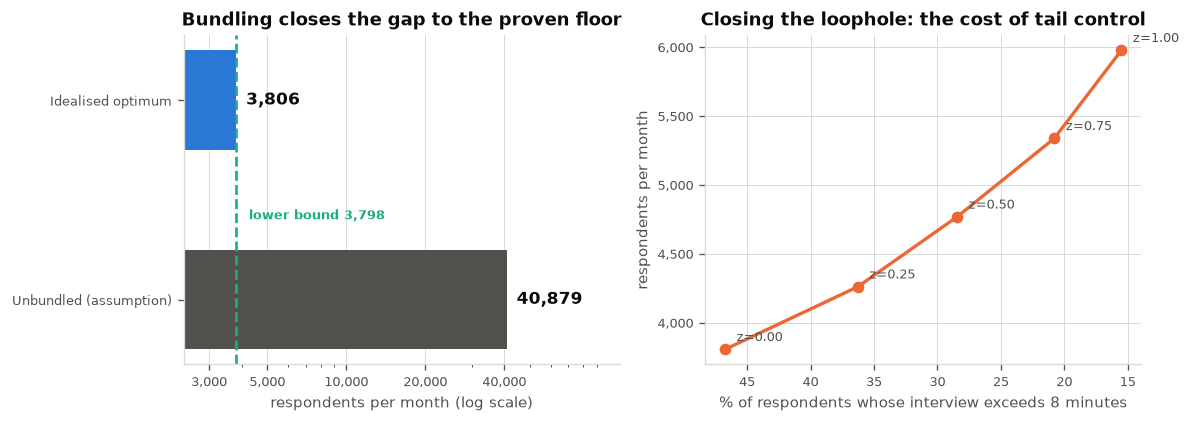

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

# (a) cost comparison - magnitude, so bars; log x because the range spans 11x
a0 = ax[0]
bound_final = lower_bound(E, p, L)[0]
vals = [naive.sum(), xm.sum()]
bars = a0.barh(['Unbundled (assumption)', 'Idealised optimum'], vals,
               color=[MUTED, BLUE], height=.5)
for b_, v_ in zip(bars, vals):
    a0.text(v_*1.09, b_.get_y()+b_.get_height()/2, f'{v_:,.0f}', va='center',
            fontsize=10, color=INK, fontweight='bold')
a0.axvline(bound_final, color=AQUA, linewidth=1.6, linestyle='--', zorder=1)
a0.text(bound_final*1.12, 0.42, f'lower bound {bound_final:,.0f}', ha='left', va='center',
        fontsize=8, color=AQUA, fontweight='bold')
a0.set_xscale('log'); a0.set_xlim(2.4e3, 1.1e5)
a0.set_xticks([3000, 5000, 10000, 20000, 40000])
a0.xaxis.set_major_formatter(thousands)
a0.xaxis.set_minor_formatter(FuncFormatter(lambda v, _: ''))
a0.set_xlabel('respondents per month (log scale)')
a0.set_title('Bundling closes the gap to the proven floor')
a0.grid(axis='y', visible=False)

# (b) the cost-of-realism frontier - relationship between two measures, so a line
a1 = ax[1]
fx = [f['over'] for f in frontier]; fy = [f['N'] for f in frontier]
a1.plot(fx, fy, color=ORANGE, marker='o', markersize=6, zorder=3)
for f_ in frontier:
    a1.annotate(f'z={f_["z"]:.2f}', (f_['over'], f_['N']), textcoords='offset points',
                xytext=(7, 5), fontsize=7.5, color=MUTED)
a1.set_xlabel('% of respondents whose interview exceeds 8 minutes')
a1.set_ylabel('respondents per month')
a1.yaxis.set_major_formatter(thousands)
a1.set_title('Closing the loophole: the cost of tail control')
a1.invert_xaxis()
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7.5 Respondent burden: the constraint the 0-second assumption hides

The brief allows qualifiers to cost 0 seconds but flags that *"there is a practical limit to how
many qualifiers can be shown to a single respondent"*. Everything so far has exploited the
assumption freely: the design puts **8 to 15 qualifiers** on each respondent. So how much does
realism cost?

It turns out this is not a separate problem. Mean qualifiers per respondent is just
`sum(E_i) / N`, so a cap of `Q` qualifiers per respondent is **a third term in the same lower
bound** derived in section 2:

$$N \;\ge\; \max\left(\underbrace{\frac{\sum_i E_i c_i}{480}}_{\text{work}},\;\;
\underbrace{\max_i E_i}_{\text{exposure}},\;\;
\underbrace{\frac{\sum_i E_i}{Q}}_{\text{burden}}\right)$$

The burden term has nothing to do with time. It says only that a fixed amount of *screening*
has to be spread over enough people.

In [14]:
# The 2-D DP (capacity x cardinality) needs a coarser grid than the 1-D one to stay in memory.
# Weights still round UP, so a DP-feasible version remains genuinely feasible - the coarser
# grid costs a little tightness, never validity.
SCALE = 10

sumE = int(E.sum())
work_s = float((E * c).sum())
print(f'sum(E_i) = {sumE:,d} qualifier-exposures to place over N respondents')
print(f'current design: {sumE/xm.sum():.2f} qualifiers on the average respondent\n')

print(f'{"Q":>4s}{"work":>9s}{"exposure":>10s}{"burden":>9s}{"=> N >=":>10s}{"binding":>11s}')
burden_rows = []
for Q in (16, 14, 12, 11, 10, 9, 8, 6, 4):
    terms = {'work': work_s/CAP, 'exposure': float(E.max()), 'burden': sumE/Q}
    b = max(terms, key=terms.get)
    burden_rows.append((Q, terms[b], b))
    print(f'{Q:>4d}{terms["work"]:>9,.0f}{terms["exposure"]:>10,.0f}{terms["burden"]:>9,.0f}'
          f'{terms[b]:>10,.0f}{b:>11s}')
print(f'\nThe burden term takes over below Q = {sumE/(work_s/CAP):.1f} qualifiers per respondent.')

sum(E_i) = 44,791 qualifier-exposures to place over N respondents
current design: 11.77 qualifiers on the average respondent

   Q     work  exposure   burden   => N >=    binding
  16    3,798     2,337    2,799     3,798       work
  14    3,798     2,337    3,199     3,798       work
  12    3,798     2,337    3,733     3,798       work
  11    3,798     2,337    4,072     4,072     burden
  10    3,798     2,337    4,479     4,479     burden
   9    3,798     2,337    4,977     4,977     burden
   8    3,798     2,337    5,599     5,599     burden
   6    3,798     2,337    7,465     7,465     burden
   4    3,798     2,337   11,198    11,198     burden

The burden term takes over below Q = 11.8 qualifiers per respondent.


### The constraints are complements, not additive costs

The bound is a `max`, not a sum. So once the burden term dominates, tail control is paid for
already: spreading the same screening load over more respondents *also* shortens each interview.
Solving the LP under both constraints jointly confirms it.

In [15]:
def fieldable(E, zl, Q=None, fam_cap=None, cv=CV_REF):
    kw = {}
    if Q is not None: kw['max_cats'] = Q
    if fam_cap is not None: kw['family'] = gid; kw['fam_cap'] = fam_cap
    r_, mn, vr = tail_design(E, p, L, cv, zl, **kw)
    Vf_, xf_, cov_ = round_design(r_['versions'], r_['x'], E)
    return Vf_, xf_, cov_, mn, vr

print(f'{"":>12s}' + ''.join(f'{f"Q<={q}":>11s}' for q in (12, 10, 8)) + '     (N)')
grid = {}
for zl, lab in ((0.0, 'no tail ctl'), (0.25, 'z = 0.25'), (0.50, 'z = 0.50')):
    line = f'{lab:>12s}'
    for Q in (12, 10, 8):
        Vg, xg, _, mng, _ = fieldable(E, zl, Q)
        grid[(zl, Q)] = int(xg.sum())
        line += f'{xg.sum():>11,d}'
    print(line)
print(f'\nAt Q<=10, moving from no tail control to z=0.25 costs '
      f'{100*(grid[(0.25,10)]/grid[(0.0,10)]-1):+.2f}% - it is free.')
print(f'At Q<=8 it is free up to z=0.50 ({100*(grid[(0.5,8)]/grid[(0.0,8)]-1):+.2f}%).')
print('A design forced to be realistic about screener burden gets the data-quality fix thrown in.')

                  Q<=12      Q<=10       Q<=8     (N)


 no tail ctl      3,811      4,488      5,605


    z = 0.25      4,265      4,488      5,606


    z = 0.50      4,774      4,772      5,606

At Q<=10, moving from no tail control to z=0.25 costs +0.00% - it is free.
At Q<=8 it is free up to z=0.50 (+0.02%).
A design forced to be realistic about screener burden gets the data-quality fix thrown in.


### Two levers that beat the frontier

**Qualifier de-duplication (tier A).** Categories sharing a screening question can be asked once
and routed to both surveys. This is the only lever that cuts *questions asked* without raising
`N`, because it leaves exposure untouched. It requires the shared-qualifier group to sit on the
**same** respondent.

**Hierarchical screener trees (tier C).** Ask one cluster gate, then members only if it passes:
expected questions `1 + P(union)*k` against a flat `k`. This only wins when the cluster is
unlikely to pass, and **correlation makes it better** because correlated members make the union
probability closer to the max rather than to 1. That is the opposite of correlation's effect on
the length tail.

In [16]:
print(f'{"cluster":<16s}{"k":>3s}{"P(union) ind":>14s}{"ask":>7s}{"P(union) rho":>14s}{"ask":>7s}')
flat = t_ind = t_rho = 0
for cl, mem in CLUSTERS.items():
    ii = [idx[m] for m in mem]; k = len(ii); pv = p[ii]
    pu_i = 1 - np.prod(1 - pv)                          # independent union
    pu_r = max(pv.min(), 1 - np.prod(1 - pv)**0.45)     # correlated union -> nearer max(p)
    ai, ar = 1 + pu_i*k, 1 + pu_r*k
    flat += k; t_ind += min(ai, k); t_rho += min(ar, k)
    print(f'{cl:<16s}{k:>3d}{pu_i:>14.2f}{ai:>7.2f}{pu_r:>14.2f}{ar:>7.2f}'
          f'   {"saves" if ar < k else "COSTS MORE"}')
print(f'\nflat list {flat} questions -> {t_ind:.1f} independent / {t_rho:.1f} correlated')
print('Confectionery and investing are worse with a gate: their union probability is so high')
print('that the gate almost never lets anyone skip, so it is a pure extra question.')

shared_saving = sum(len(v) for v in SHARED_QUALIFIER.values()) - len(SHARED_QUALIFIER)
print(f'\nTier A de-duplication removes {shared_saving} asked questions outright, for free,')
print(f'provided each shared-qualifier group is co-located on the same respondent.')

cluster           k  P(union) ind    ask  P(union) rho    ask
alcohol           6          0.94   6.64          0.72   5.31   saves
baby              4          0.66   3.64          0.38   2.54   saves
confectionery     4          1.00   4.99          0.94   4.78   COSTS MORE
car_ownership     3          0.87   3.60          0.60   2.79   saves
vehicle_rental    2          0.50   1.99          0.27   1.54   saves
investing         3          0.92   3.76          0.68   3.03   COSTS MORE
bnpl              2          0.61   2.21          0.35   1.70   saves
skincare          5          0.95   5.73          0.73   4.66   saves
womens_fashion    4          0.90   4.58          0.64   3.55   saves
outdoor           3          0.90   3.69          0.64   2.92   saves

flat list 36 questions -> 35.6 independent / 32.0 correlated
Confectionery and investing are worse with a gate: their union probability is so high
that the gate almost never lets anyone skip, so it is a pure extra question.

Ti

### The design tension, and how it resolves

De-duplication wants near-duplicate qualifiers **co-located**. The length tail wants correlated
categories **spread apart**. These pull in opposite directions on the same category pairs.

They resolve because they act at different levels. Tier A is three small groups where the
question is genuinely the same, so co-locating costs almost no diversity. Tier C is the broader
co-purchase structure, and section 9.5 shows capping it is free. So both can be had at once.

**Recommended fieldable design:** `Q <= 10` qualifiers per respondent, at most 2 categories from
any co-purchase cluster, and `z = 0.25` tail control.

In [17]:
Vf, xf, cover_f, mean_f, var_f = fieldable(E, 0.25, Q=10, fam_cap=2)
clust_per_version = np.array([[(gid[v > 0] == f).sum() for f in range(len(CLUSTERS))] for v in Vf])
T_f = simulate_lengths(np.random.default_rng(SEED+3), Vf, xf, p, L, CV_REF, gid, 0.0, reps=3)
bound_f = max(work_s/float((Vf @ mean_f).max()), sumE/10, float(E.max()))

print(f'FIELDABLE DESIGN            N = {xf.sum():,d} respondents/month')
print(f'  vs qualifier cap alone      {grid[(0.0,10)]:,d}   ({100*(xf.sum()/grid[(0.0,10)]-1):+.2f}%)')
print(f'  vs idealised design         {xm.sum():,d}   ({100*(xf.sum()/xm.sum()-1):+.1f}%)')
print(f'  vs three-term bound         {bound_f:,.0f}   ({100*(xf.sum()/bound_f-1):+.2f}% gap)')
print(f'  max qualifiers/respondent   {Vf.sum(1).max()}')
print(f'  max categories per cluster  {clust_per_version.max()}')
print(f'  mean interview load         {(Vf @ mean_f).max():.0f}s')
print(f'  P(interview > 480s)         {100*(T_f > CAP).mean():.1f}%  '
      f'(was {100*(simulate_lengths(np.random.default_rng(SEED+3), Vm, xm, p, L, CV_REF, gid, 0.0, reps=3) > CAP).mean():.1f}%)')
print(f'  survey versions             {(xf > 0).sum()}')
assert Vf.sum(1).max() <= 10,          'qualifier cap must hold on every version'
assert clust_per_version.max() <= 2,   'anti-affinity cap must hold on every version'
assert (cover_f >= E).all(),           'every category must still reach its exposure target'
assert xf.sum() >= bound_f - 1,        'cannot beat the three-term bound'
print('\nasserts passed: qualifier cap, cluster cap, coverage, and the three-term bound all hold.')

FIELDABLE DESIGN            N = 4,486 respondents/month
  vs qualifier cap alone      4,488   (-0.04%)
  vs idealised design         3,806   (+17.9%)
  vs three-term bound         4,479   (+0.15% gap)
  max qualifiers/respondent   10
  max categories per cluster  2
  mean interview load         434s
  P(interview > 480s)         33.0%  (was 46.0%)
  survey versions             77

asserts passed: qualifier cap, cluster cap, coverage, and the three-term bound all hold.


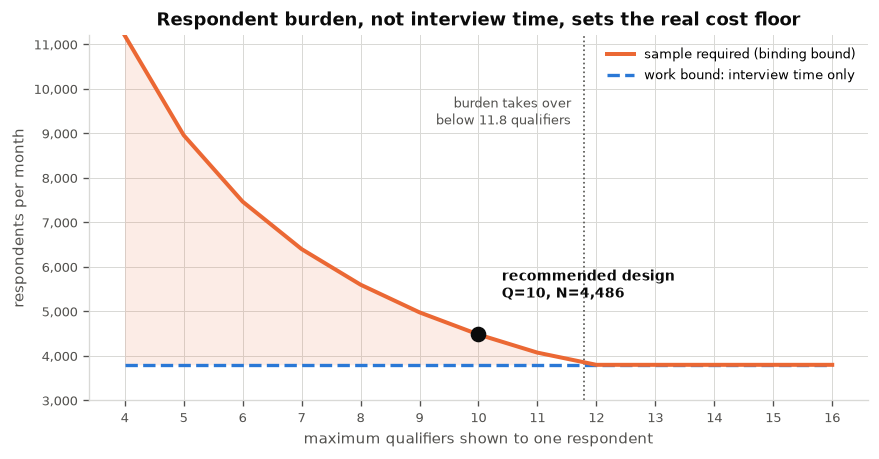

In [18]:
fig, ax = plt.subplots(figsize=(7.4, 3.9))
Qs = np.arange(4, 17)
work_line  = np.full_like(Qs, work_s/CAP, dtype=float)
burden_line = sumE / Qs
binding     = np.maximum(work_line, burden_line)

ax.plot(Qs, binding, color=ORANGE, linewidth=2.4, zorder=3, label='sample required (binding bound)')
ax.plot(Qs, work_line, color=BLUE, linewidth=2, linestyle='--', zorder=2,
        label='work bound: interview time only')
ax.fill_between(Qs, work_line, binding, where=burden_line > work_line, color=ORANGE,
                alpha=.12, linewidth=0, zorder=1)

qx = sumE/(work_s/CAP)
ax.axvline(qx, color=MUTED, linewidth=1, linestyle=':', zorder=1)
ax.annotate(f'burden takes over\nbelow {qx:.1f} qualifiers', (qx, 9200), xytext=(-8, 0),
            textcoords='offset points', ha='right', fontsize=8, color=MUTED)
ax.scatter([10], [xf.sum()], s=70, color=INK, zorder=5)
ax.annotate(f'recommended design\nQ=10, N={xf.sum():,d}', (10, xf.sum()), xytext=(14, 22),
            textcoords='offset points', fontsize=8.5, color=INK, fontweight='bold')

ax.set_xlabel('maximum qualifiers shown to one respondent')
ax.set_ylabel('respondents per month')
ax.yaxis.set_major_formatter(thousands); ax.set_xticks(Qs)
ax.set_ylim(3000, 11200)
ax.set_title('Respondent burden, not interview time, sets the real cost floor')
ax.legend(loc='upper right')
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 What this implies for pricing

Burden binding rather than time changes what a category costs to serve. Cost per category is
`max( T*L/480 , T/(p*Q) )` - interview time on the left, screening slots on the right - and the
two cross at `p*L = 480/Q`.

Give the optimiser unlimited screening and incidence barely matters: cost is almost pure survey
length, and section 2 showed incidence only binds below 5.7%. Cap screening at a realistic `Q` and
a hard-to-find category starts consuming the scarce resource while using almost no interview time.
Incidence comes back as a first-order cost driver for half the book.

In [19]:
Q_REC = int(Vf.sum(1).max())       # qualifier cap the recommended design actually uses

# Marginal cost of one more category: whichever of the two binding terms is larger. E_i is the
# exposure the monthly guarantee requires (section 4), so this prices the policy we ship.
work_term   = E * c / CAP              # interview-time capacity consumed
burden_term = E / Q_REC                # screening slots consumed
marginal    = np.maximum(work_term, burden_term)

print('Marginal cost of onboarding one more category (respondents/month)')
print(f'   standalone survey   {naive.mean():>6.0f}')
print(f'   inside the bundle   {marginal.mean():>6.0f}   '
      f'({naive.mean()/marginal.mean():.1f}x cheaper), range {marginal.min():.0f}-{marginal.max():.0f}\n')

saved_yr = int(round(naive.sum() - xf.sum())) * 12
print(f'Against the unbundled ASSUMPTION ({naive.sum():,.0f}/month), bundling saves '
      f'{saved_yr:,d} respondents a year:')
for cpi in (3, 5, 8, 12):
    print(f'   at ${cpi:>2d} per completed interview  ->  ${saved_yr*cpi/1e6:>5.2f}M per year')
print('\nSample cost per completed interview is Tracksuit\'s number, not mine, so it stays a')
print('parameter. The respondent volumes are the model output.')

Marginal cost of onboarding one more category (respondents/month)
   standalone survey      531
   inside the bundle       67   (7.9x cheaper), range 25-234

Against the unbundled ASSUMPTION (40,879/month), bundling saves 436,716 respondents a year:
   at $ 3 per completed interview  ->  $ 1.31M per year
   at $ 5 per completed interview  ->  $ 2.18M per year
   at $ 8 per completed interview  ->  $ 3.49M per year
   at $12 per completed interview  ->  $ 5.24M per year

Sample cost per completed interview is Tracksuit's number, not mine, so it stays a
parameter. The respondent volumes are the model output.


In [20]:
xover = CAP / Q_REC
n_inc = int((c < xover).sum())
print(f'crossover at incidence x length = {xover:.0f}s   ->   '
      f'{n_cat-n_inc} length-driven, {n_inc} incidence-driven\n')
print(f'{"":<36s}{"incid.":>8s}{"length":>8s}{"resp/mo":>9s}{"driver":>11s}')
for tag, order in (('most expensive to serve', np.argsort(-marginal)[:5]),
                   ('cheapest to serve',       np.argsort(marginal)[:2])):
    print(tag)
    for i in order:
        drv = 'incidence' if burden_term[i] > work_term[i] else 'length'
        print(f'   {names[i]:<33s}{p[i]:>8.2f}{L[i]:>7.0f}s{marginal[i]:>9.0f}{drv:>11s}')
print(f'\nA flat price cross-subsidises the {n_inc} incidence-driven categories from the '
      f'{n_cat-n_inc} length-driven ones.')
print(f'The most expensive category to serve costs '
      f'{marginal.max()/marginal.mean():.1f}x the average.')

crossover at incidence x length = 48s   ->   37 length-driven, 40 incidence-driven

                                      incid.  length  resp/mo     driver
most expensive to serve
   Fertility or IVF service             0.10    165s      234  incidence
   Big and Tall Men's Clothing          0.13     70s      170  incidence
   Baby products                        0.19     60s      118  incidence
   Self Tan (Female Only)               0.19    116s      116  incidence
   Baby Feeding                         0.20    166s      112  incidence
cheapest to serve
   Chips, Crisps, Crackers              0.85     43s       25  incidence
   Coffee                               0.79     69s       30     length

A flat price cross-subsidises the 40 incidence-driven categories from the 37 length-driven ones.
The most expensive category to serve costs 3.5x the average.


### 7.7 The commercial picture

Everything above is in respondents. This converts it into the three numbers a commercial owner
actually decides on: what the sample bill is, what the service-level promise costs, and how far
cost-to-serve varies across a book that is priced flat.

Cost per completed interview is Tracksuit's number, not mine, so it stays a parameter throughout.

In [21]:
CPI  = (3, 5, 8, 12)                 # $ per completed interview - carried as a parameter
N_mo = int(xf.sum()); N_yr = N_mo * 12

print('THE SAMPLE BILL')
for cpi in CPI:
    print(f'   at ${cpi:>2d} per complete   {N_yr:,d} respondents/year  ->  '
          f'${N_yr*cpi/1e6:>5.2f}M per year')

print('\nWHAT THE SERVICE LEVEL COSTS   (respondents/month, at the binding floor)')
f_mean = floor_at(np.ceil(200/p).astype(int))
f_pool = floor_at(exposure_needed(ANNUAL, MONTHS, p))
f_guar = floor_at(E_month(p))
f_99   = floor_at(E_month(p, 2.326))
for lab, f_ in (('deliver 200 on average - misses half the months', f_mean),
                ('annual 2,400 pooled - the contract as written',   f_pool),
                ('200 every month, 95% of months  <- shipped',      f_guar),
                ('200 every month, 99% of months',                  f_99)):
    print(f'   {lab:48s}{f_:>8,.0f}{100*(f_/f_mean-1):>+8.1f}%')

d_yr = (f_guar - f_mean) * 12
print(f'\n   The guarantee costs {f_guar-f_mean:,.0f} respondents a month, {d_yr:,.0f} a year, '
      f'over sizing to the mean.')
print(f'   {"":3s}{"$/complete":>12s}{"$/year":>12s}{"$/customer/year":>18s}')
for cpi in CPI:
    print(f'   {"":3s}{f"${cpi}":>12s}{d_yr*cpi/1000:>11,.0f}k{d_yr*cpi/n_cat:>18,.0f}')
print(f'\n   Break-even: across the whole book the guarantee is paid for by retaining roughly one')
print(f'   customer a year on a contract worth more than ${d_yr*5/1000:,.0f}k. That is the trade -')
print('   a few hundred dollars of sample per customer against the churn risk of a light month.')

print('\nCOST TO SERVE IS NOT FLAT, BUT PRICE IS')
print(f'   cheapest category {marginal.min():>3.0f} respondents/month, dearest '
      f'{marginal.max():>3.0f} - a {marginal.max()/marginal.min():.1f}x spread')
print(f'   at $5 per complete that is ${12*marginal.min()*5:,.0f} to '
      f'${12*marginal.max()*5:,.0f} of sample per category per year')
print(f'   {n_inc} of {n_cat} categories sit on the incidence side of the crossover; those are the')
print('   ones a flat price under-recovers, and the gap is a margin leak rather than a rounding')
print('   error.')

print('\nGROWTH')
print(f'   a new category costs {marginal.mean():>3.0f} respondents/month inside the bundle '
      f'against {naive.mean():,.0f} standalone')
print(f'   at $5 per complete   ${12*marginal.mean()*5:,.0f}/year to serve, '
      f'against ${12*naive.mean()*5:,.0f}/year standalone')
print(f'   sample stops being what limits how fast the book can grow.')

THE SAMPLE BILL
   at $ 3 per complete   53,832 respondents/year  ->  $ 0.16M per year
   at $ 5 per complete   53,832 respondents/year  ->  $ 0.27M per year
   at $ 8 per complete   53,832 respondents/year  ->  $ 0.43M per year
   at $12 per complete   53,832 respondents/year  ->  $ 0.65M per year

WHAT THE SERVICE LEVEL COSTS   (respondents/month, at the binding floor)
   deliver 200 on average - misses half the months    4,092    +0.0%
   annual 2,400 pooled - the contract as written      4,200    +2.6%
   200 every month, 95% of months  <- shipped         4,479    +9.5%
   200 every month, 99% of months                     4,650   +13.7%

   The guarantee costs 388 respondents a month, 4,650 a year, over sizing to the mean.
        $/complete      $/year   $/customer/year
                $3         14k               181
                $5         23k               302
                $8         37k               483
               $12         56k               725

   Break-even: a

---
## 8. Representativeness decouples from the packing

**The structural result.** A category's exposed sample is the union of the versions containing
it. So if *every version's* respondent pool is nationally representative, then every category's
exposed sample is a mixture of representative samples - representative too, for all 77
categories at once, **at zero cost to the objective**. Representativeness and packing are
orthogonal problems.

Implementation: express the design as version *shares*, then allocate respondents to versions
in the same proportions inside every demographic cell. This is deterministic, so unlike
randomised assignment (unbiased but noisy) there is no month-to-month sampling variance.

**Where it gets hard, and the honest fix.** A version holds ~47 respondents while a fully
interlocked gender × age × region frame has 60 cells. Rounding each version independently puts
the spare respondent in the same large cells every time, so the bias *compounds*. Worse, a
category is an **arbitrary union** of versions, and no construction makes every union balanced.

So rather than trusting a construction, we optimise the assignment directly. 2×2 swaps
(`A[k₁,v₁]--, A[k₁,v₂]++, A[k₂,v₁]++, A[k₂,v₂]--`) preserve both margins exactly, so
feasibility is never at risk, and we accept swaps that reduce total squared marginal deviation.

The frame below is **synthetic** - the dataset has no demographic columns. It is a documented
placeholder with NZ-shaped marginals; swap in the real census joint distribution and nothing
else changes.

In [22]:
FRAME = {'gender': {'Male': .49, 'Female': .51},
         'age':    {'18-24': .13, '25-34': .19, '35-44': .17, '45-54': .17,
                    '55-64': .15, '65+': .19},
         'region': {'Auckland': .34, 'Wellington': .11, 'Rest of North Is.': .25,
                    'Canterbury': .13, 'Rest of South Is.': .17}}

def build_cells(frame=FRAME):
    keys = list(frame)
    combos = list(itertools.product(*[frame[k].items() for k in keys]))
    labels = [tuple(c_[0] for c_ in combo) for combo in combos]
    w = np.array([np.prod([c_[1] for c_ in combo]) for combo in combos])
    return labels, w/w.sum()

def marginal_operator(labels, frame=FRAME):
    rows, tgt, nm_ = [], [], []
    for ki, k in enumerate(frame):
        for lv in frame[k]:
            rows.append(np.array([1. if lab[ki] == lv else 0. for lab in labels]))
            tgt.append(frame[k][lv]); nm_.append(f'{k}:{lv}')
    return np.array(rows), np.array(tgt), nm_

def allocate_strata(x, w):
    '''Low-discrepancy starting allocation: cells and versions are both spread evenly
    over the same axis, so a version takes a systematic sample of the cell sequence
    rather than a contiguous block.'''
    PHI = 0.6180339887498949
    N = int(np.sum(x)); n = np.floor(w*N).astype(int)
    short = N - n.sum()
    if short > 0: n[np.argsort(-(w*N - n))[:short]] += 1
    def spread(sizes):
        ks, lb = [], []
        for g, m in enumerate(sizes):
            if m <= 0: continue
            ks.append(((np.arange(m) + ((g*PHI) % 1.))/m) % 1.); lb.append(np.full(m, g))
        ks, lb = np.concatenate(ks), np.concatenate(lb)
        return lb[np.argsort(ks, kind='stable')]
    A = np.zeros((len(w), len(x)), dtype=int)
    np.add.at(A, (spread(n), spread(np.asarray(x, int))), 1)
    return A

def category_cell_shares(A, versions):
    ex = A @ versions
    return ex/ex.sum(0, keepdims=True)

def balance_strata(A, versions, M, tgt, iters=40000, seed=SEED):
    '''2x2 swaps preserve both margins exactly; accept those that cut squared deviation.'''
    rng = np.random.default_rng(seed); A = A.copy(); K, Vn = A.shape
    def obj(A):
        sh = category_cell_shares(A, versions)
        return float((((M @ sh) - tgt[:, None])**2).sum())
    best = obj(A)
    for t in range(iters):
        if t % 2:                                    # guided at the worst residual
            dev = (M @ category_cell_shares(A, versions)) - tgt[:, None]
            m_, i_ = np.unravel_index(np.argmax(np.abs(dev)), dev.shape)
            inl = M[m_] > 0
            over = inl if dev[m_, i_] > 0 else ~inl
            vs = np.flatnonzero(versions[:, i_] > 0)
            if len(vs) == 0 or not over.any() or not (~over).any(): continue
            k1 = rng.choice(np.flatnonzero(over)); k2 = rng.choice(np.flatnonzero(~over))
            v1 = rng.choice(vs); v2 = rng.integers(Vn)
        else:
            k1, k2 = rng.integers(K, size=2); v1, v2 = rng.integers(Vn, size=2)
        if k1 == k2 or v1 == v2 or A[k1, v1] == 0 or A[k2, v2] == 0: continue
        A[k1, v1] -= 1; A[k1, v2] += 1; A[k2, v1] += 1; A[k2, v2] -= 1
        cur = obj(A)
        if cur < best: best = cur
        else: A[k1, v1] += 1; A[k1, v2] -= 1; A[k2, v1] -= 1; A[k2, v2] += 1
    return A

cell_labels, w_cell = build_cells()
M_marg, tgt_marg, marg_names = marginal_operator(cell_labels)
A_raw = allocate_strata(xf, w_cell)   # the fieldable design from 7.5
A_bal = balance_strata(A_raw, Vf, M_marg, tgt_marg)

for tag, A_ in (('construction only', A_raw), ('+ swap balancing', A_bal)):
    sh = category_cell_shares(A_, Vf); d = np.abs((M_marg @ sh) - tgt_marg[:, None])
    print(f'{tag:20s} marginal deviation  max {100*d.max():5.3f} pp   mean {100*d.mean():5.3f} pp')

dev_marg = np.abs((M_marg @ category_cell_shares(A_bal, Vf)) - tgt_marg[:, None])
assert (A_bal.sum(0) == xf).all(),  'version totals must be preserved exactly'
assert dev_marg.max() < 0.02,       'marginal quota deviation must stay within 2pp'
print(f'\nrespondents per version preserved exactly: {bool((A_bal.sum(0)==xf).all())}')
print(f'worst residual is on the smallest exposed samples - exposure ranges '
      f'{cover_f.min():,d}-{cover_f.max():,d} respondents,')
print(f'and 1 respondent in {cover_f.min():,d} is already {100/cover_f.min():.2f} pp of granularity.')

construction only    marginal deviation  max 9.607 pp   mean 1.397 pp
+ swap balancing     marginal deviation  max 0.825 pp   mean 0.247 pp

respondents per version preserved exactly: True
worst residual is on the smallest exposed samples - exposure ranges 236-2,340 respondents,
and 1 respondent in 236 is already 0.42 pp of granularity.


### 8.1 The data flags its own non-uniform incidence

Five categories are explicitly gender-restricted by name - *Self Tan (Female Only)*,
*Women's Activewear (Female Only)*, *Men's Clothing (Male Only)*, *Female Skincare*,
*Skincare (Female Only)*. Their national incidence implies a roughly doubled rate within the
eligible gender.

Two consequences, and note the first is **not** an optimisation opportunity:

- You **cannot** economise by screening only women for Self Tan. The brief requires the
  *exposed* sample to be nationally representative, so the wasted exposure is mandatory.
  Gender-restricted categories are structurally ~2× more expensive to serve, and that belongs
  in pricing rather than in the optimiser.
- Expected interview length then differs **by cell** - women carry the beauty, baby and period
  categories - so the 480s rule should be checked per cell, not just nationally.

In [23]:
gendered = ['Self Tan (Female Only)', "Women's Activewear (Female Only)",
            "Men's Clothing (Male Only)", 'Female Skincare', 'Skincare (Female Only)']
fem = np.array([lab[0] == 'Female' for lab in cell_labels])
exposed_cells = A_bal @ Vf

print(f'{"category":34s}{"national p":>11s}{"implied p in-gender":>21s}{"cost multiplier":>17s}')
for g in gendered:
    i = idx[g]; share = .51 if 'Female' in g or 'Female Only' in g else .49
    print(f'{g:34s}{p[i]:11.3f}{p[i]/share:>21.3f}{1/share:>16.2f}x')

load_f = (exposed_cells[fem].sum(0) @ (Vf * c).sum(1)) / max(exposed_cells[fem].sum(), 1)
load_m = (exposed_cells[~fem].sum(0) @ (Vf * c).sum(1)) / max(exposed_cells[~fem].sum(), 1)
print(f'\nmean expected interview length by gender under the current (uniform-incidence) model:')
print(f'   female {load_f:.1f}s   male {load_m:.1f}s')
print('These are equal by construction because the model assumes incidence does not vary by')
print('cell. With true cell-level incidence the female load would rise and could breach 480s')
print('while the national mean still passed - the check to run once real cell data exists.')

category                           national p  implied p in-gender  cost multiplier
Self Tan (Female Only)                  0.191                0.375            1.96x
Women's Activewear (Female Only)        0.375                0.735            1.96x
Men's Clothing (Male Only)              0.327                0.667            2.04x
Female Skincare                         0.443                0.870            1.96x
Skincare (Female Only)                  0.426                0.835            1.96x

mean expected interview length by gender under the current (uniform-incidence) model:
   female 391.5s   male 391.6s
These are equal by construction because the model assumes incidence does not vary by
cell. With true cell-level incidence the female load would rise and could breach 480s
while the national mean still passed - the check to run once real cell data exists.


---
## 9. Validation: a 12-month closed-loop rollout

The brief asks for a simulation over a month; because the planner re-runs monthly, a full year
with **re-planning each month** is the right test and strictly contains it.

The section 1 separation makes this cheap: delivery for category `i` is `Binomial(E_i, p_i)` and does
not depend on the packing, so thousands of replicate years can be simulated on exposures alone.
Each month: plan → field → observe → update the Beta posterior on `p` → re-plan.

In [24]:
def rollout(rng, p_true, months=MONTHS, annual=ANNUAL, z=Z_SERVICE, floor_frac=0.0,
            reps=2000, learn_p=True, guarantee=True):
    n = len(p_true)
    delivered = np.zeros((reps, n)); exposure = np.zeros((reps, months, n))
    monthly_q = np.zeros((reps, months, n))
    a0, b0 = prior_ab(p_true)
    a = np.tile(a0, (reps, 1)); b = np.tile(b0, (reps, 1))
    for m in range(months):
        p_plan = plan_p(a, b) if learn_p else np.broadcast_to(p_true, (reps, n))
        E_m = exposure_needed(annual - delivered, months - m, p_plan, z, floor_frac)
        if guarantee:                              # never plan below a 95% month
            E_m = np.maximum(E_m, E_month(p_plan, z))
        q = rng.binomial(E_m, p_true)
        delivered += q; exposure[:, m] = E_m; monthly_q[:, m] = q
        a = a + q; b = b + (E_m - q)
    return delivered, exposure, monthly_q

delivered, exposure, monthly_q = rollout(np.random.default_rng(SEED), p, reps=2000)
hit = (delivered >= ANNUAL).mean(0)
hit_month = (monthly_q >= NOMINAL).mean((0, 1))          # P(month >= 200), per category
monthly_N = (exposure * c).sum(2) / CAP

print(f'P(month >= {NOMINAL}) per category  : min {hit_month.min():.3f}   '
      f'mean {hit_month.mean():.3f}   (target 0.95)')
print(f'P(annual >= {ANNUAL})            : min {hit.min():.3f}   mean {hit.mean():.3f}')
print(f'mean annual delivered        : {delivered.mean():,.0f}   '
      f'worst category {delivered.mean(0).min():,.0f}   contracted {ANNUAL:,d}')
print(f'\nmonthly cost   m1 {monthly_N[:,0].mean():,.0f}   m6 {monthly_N[:,5].mean():,.0f}   '
      f'm12 {monthly_N[:,11].mean():,.0f}')
print(f'annual total   closed loop {monthly_N.sum(1).mean():,.0f}   vs 12x static '
      f'{12*monthly_N[:,0].mean():,.0f}   ({100*(monthly_N.sum(1).mean()/(12*monthly_N[:,0].mean())-1):+.1f}%)')
assert hit_month.min() >= 0.95, 'every category must clear 200 in >=95% of months'
assert hit.min() >= 0.95,       'every category must clear its annual contract too'
print('\nasserts passed: all 77 categories clear 200 in at least 95% of months, and 2,400/year.')

P(month >= 200) per category  : min 0.979   mean 0.982   (target 0.95)
P(annual >= 2400)            : min 1.000   mean 1.000
mean annual delivered        : 2,671   worst category 2,526   contracted 2,400

monthly cost   m1 3,938   m6 3,883   m12 3,862
annual total   closed loop 46,644   vs 12x static 47,255   (-1.3%)

asserts passed: all 77 categories clear 200 in at least 95% of months, and 2,400/year.


### 9.1 What the guarantee changes, and a hypothesis it made moot

Two policies are worth putting side by side: the pooled one that satisfies the contract as
written, and the monthly guarantee this design actually ships.

Going in I expected cost under pooling to be **back-loaded**: in the final month `k = 1`, no
pooling is left, so a shortfall is expensive to repair, and I built a "risk ramp" floor to stop
the policy coasting early and arriving at December exposed. The rollout said the opposite - month
12 is the *cheapest* month, because the loop accumulates surplus through the year and spends it
down at the end.

The monthly guarantee removes that behaviour entirely. The floor stops the loop from coasting in
the first place, so there is no surplus to spend down and the monthly cost profile is flat. The
negative result stands as a finding about the pooled policy; it is simply no longer load-bearing
for the design that ships. The ramp guard is left in the code for the mid-year-churn case.

In [25]:
print('What the guarantee buys, and what the pooled alternative would have done\n')
print(f'{"policy":24s}{"m1":>8s}{"m6":>8s}{"m12":>8s}{"year":>10s}'
      f'{"min P(mo>=200)":>16s}{"min P(yr)":>11s}')
runs = {}
for guar, tag in ((False, 'annual pooled only'), (True, 'monthly guarantee')):
    d_, e_, q_ = rollout(np.random.default_rng(SEED), p, reps=2000, guarantee=guar)
    w_ = (e_ * c).sum(2) / CAP
    runs[tag] = (d_, e_, q_, w_)
    print(f'{tag:24s}{w_[:,0].mean():>8,.0f}{w_[:,5].mean():>8,.0f}{w_[:,11].mean():>8,.0f}'
          f'{w_.sum(1).mean():>10,.0f}{(q_>=NOMINAL).mean((0,1)).min():>16.3f}'
          f'{(d_>=ANNUAL).mean(0).min():>11.3f}')

wp = runs['annual pooled only'][3]; wg = runs['monthly guarantee'][3]
print(f'\nThe guarantee costs {100*(wg.sum(1).mean()/wp.sum(1).mean()-1):+.1f}% over the year and '
      f'lifts the worst category from')
print(f'{(runs["annual pooled only"][2]>=NOMINAL).mean((0,1)).min():.3f} to '
      f'{(runs["monthly guarantee"][2]>=NOMINAL).mean((0,1)).min():.3f} on the monthly number. '
      'That is the trade the design makes.')
print()
print('It also flattens the profile. Under pooling, month 12 is the CHEAPEST month '
      f'({wp[:,11].mean():,.0f} vs')
print(f'{wp[:,0].mean():,.0f} in month 1) because the loop accumulates surplus and spends it down '
      '- the opposite of the')
print('back-loaded cost I expected when I built the risk-ramp guard. Under the guarantee that '
      'dynamic')
print(f'disappears: the floor stops the loop coasting, so cost is flat ({wg[:,0].mean():,.0f} '
      f'-> {wg[:,11].mean():,.0f}) and the')
print('ramp is moot. The guard stays in the code for the churn case; it does nothing here.')

What the guarantee buys, and what the pooled alternative would have done

policy                        m1      m6     m12      year  min P(mo>=200)  min P(yr)


annual pooled only         3,708   3,569   3,139    42,219           0.563      0.969


monthly guarantee          3,938   3,883   3,862    46,644           0.979      1.000

The guarantee costs +10.5% over the year and lifts the worst category from
0.563 to 0.979 on the monthly number. That is the trade the design makes.

It also flattens the profile. Under pooling, month 12 is the CHEAPEST month (3,139 vs
3,708 in month 1) because the loop accumulates surplus and spends it down - the opposite of the
back-loaded cost I expected when I built the risk-ramp guard. Under the guarantee that dynamic
disappears: the floor stops the loop coasting, so cost is flat (3,938 -> 3,862) and the
ramp is moot. The guard stays in the code for the churn case; it does nothing here.


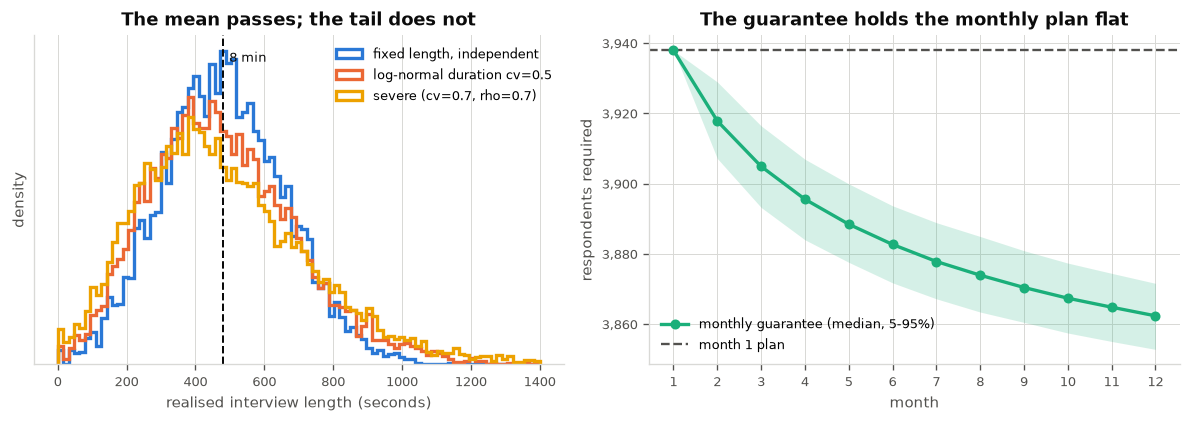

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

# (a) realised length distribution - one series per assumption, direct-labelled
a0 = ax[0]
show = [(tail_rows[0], BLUE), (tail_rows[1], ORANGE), (tail_rows[4], YELLOW)]
bins = np.linspace(0, 1400, 90)
for (lab, cv, rho, T, r_), col in show:
    a0.hist(T, bins=bins, histtype='step', linewidth=2, color=col, density=True, label=lab)
a0.axvline(CAP, color=INK, linewidth=1.2, linestyle='--')
a0.text(CAP+18, a0.get_ylim()[1]*.92, '8 min', fontsize=8, color=INK)
a0.set_xlabel('realised interview length (seconds)'); a0.set_ylabel('density')
a0.set_title('The mean passes; the tail does not')
a0.legend(loc='upper right'); a0.set_yticks([])

# (b) closed-loop trajectory - change over time
a1 = ax[1]
mo = np.arange(1, MONTHS+1)
med = np.median(monthly_N, axis=0)
a1.fill_between(mo, np.percentile(monthly_N, 5, axis=0), np.percentile(monthly_N, 95, axis=0),
                color=AQUA, alpha=.18, linewidth=0)
a1.plot(mo, med, color=AQUA, marker='o', markersize=5, zorder=3, label='monthly guarantee (median, 5-95%)')
a1.axhline(monthly_N[:, 0].mean(), color=MUTED, linewidth=1.4, linestyle='--',
           label='month 1 plan')
a1.set_xlabel('month'); a1.set_ylabel('respondents required')
a1.yaxis.set_major_formatter(thousands); a1.set_xticks(mo)
a1.set_title('The guarantee holds the monthly plan flat')
a1.legend(loc='lower left')
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig3.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9.5 Sensitivity: which assumptions actually matter

Five judgement calls feed the design. Varying each one over a plausible range separates the
inputs that change the answer from the ones that do not.

| | what it is | how it was chosen |
|---|---|---|
| `theta` | duration coefficient of variation | guessed; calibrate from paradata |
| `rho` | within-cluster co-qualification | guessed; observable in Tracksuit's own data |
| `z` | interview-length safety factor | a policy choice, not an estimate |
| `k` | max categories per co-purchase cluster | a design choice |
| `Q` | max qualifiers per respondent | an operational limit |

The anti-affinity cap `k` is the one built into the pricer in section 3 and not previously
exercised. It exists because nothing in the objective stops the optimiser concentrating a whole
co-purchase cluster on one respondent, which is exactly where correlated qualification would do
the most damage to the length tail.

In [27]:
print('COST sensitivity (N, respondents/month)\n')
print(f'{"anti-affinity cap k":<26s}{"N":>9s}{"vs uncapped":>13s}{"max/cluster":>13s}')
base_r = solve(E, c); Vb, xb, _ = round_design(base_r['versions'], base_r['x'], E)
mx = lambda V: max((gid[v > 0] == f).sum() for v in V for f in range(len(CLUSTERS)))
print(f'{"uncapped":<26s}{xb.sum():>9,d}{"-":>13s}{mx(Vb):>13d}')
for k_ in (3, 2):
    r_ = solve(E, c, family=gid, fam_cap=k_)
    Vk, xk, _ = round_design(r_['versions'], r_['x'], E)
    print(f'{f"k = {k_}":<26s}{xk.sum():>9,d}{100*(xk.sum()/xb.sum()-1):>+12.2f}%{mx(Vk):>13d}')
print('\nThe cap is free. Nothing is given up by refusing to concentrate a cluster, so it should')
print('simply always be on - insurance against a correlation structure we only partly know.')

print(f'\n{"qualifier cap Q":<26s}{"N":>9s}{"vs uncapped":>13s}')
for Q_ in (12, 10, 8, 6):
    r_ = solve(E, c, max_cats=Q_); _, xq, _ = round_design(r_['versions'], r_['x'], E)
    print(f'{f"Q = {Q_}":<26s}{xq.sum():>9,d}{100*(xq.sum()/xb.sum()-1):>+12.1f}%')
print('Q is the expensive one, and the only constraint here that a customer would never see.')

COST sensitivity (N, respondents/month)

anti-affinity cap k               N  vs uncapped  max/cluster


uncapped                      3,809            -            4


k = 3                         3,806       -0.08%            3


k = 2                         3,805       -0.11%            2

The cap is free. Nothing is given up by refusing to concentrate a cluster, so it should
simply always be on - insurance against a correlation structure we only partly know.

qualifier cap Q                   N  vs uncapped


Q = 12                        3,811        +0.1%


Q = 10                        4,488       +17.8%


Q = 8                         5,605       +47.2%


Q = 6                         7,471       +96.1%
Q is the expensive one, and the only constraint here that a customer would never see.


In [28]:
print('TAIL sensitivity of the fieldable design (cost is unaffected by theta and rho)\n')
print(f'{"theta":>7s}{"rho":>7s}{"mean":>8s}{"p50":>7s}{"p90":>7s}{"p99":>7s}{">480s":>9s}')
for cv_, rho_ in ((0.0, 0.0), (0.5, 0.0), (0.5, 0.5), (0.7, 0.7)):
    T = simulate_lengths(np.random.default_rng(SEED+11), Vf, xf, p, L, cv_, gid, rho_, reps=3)
    print(f'{cv_:>7.1f}{rho_:>7.1f}{T.mean():>8.0f}{np.percentile(T,50):>7.0f}'
          f'{np.percentile(T,90):>7.0f}{np.percentile(T,99):>7.0f}{100*(T>CAP).mean():>8.1f}%')
print('\nMean is invariant, as in section 6. theta drives the tail; rho barely moves it, because')
print('the cluster cap now prevents the concentration that would have made correlation bite.')
print('So the taxonomy in section 5 is an input the design is NOT sensitive to - which is the')
print('most useful thing to be able to say about a judgement-based input.')

TAIL sensitivity of the fieldable design (cost is unaffected by theta and rho)

  theta    rho    mean    p50    p90    p99    >480s
    0.0    0.0     404    400    625    811    31.9%
    0.5    0.0     403    383    671    956    31.6%
    0.5    0.5     403    383    670    968    32.0%


    0.7    0.7     402    369    702   1112    31.5%

Mean is invariant, as in section 6. theta drives the tail; rho barely moves it, because
the cluster cap now prevents the concentration that would have made correlation bite.
So the taxonomy in section 5 is an input the design is NOT sensitive to - which is the
most useful thing to be able to say about a judgement-based input.


---
## 10. Validation: one month, simulated end to end

Sections 6 to 9 test each constraint on its own. The brief asks for something more specific: a
simulation of how the **pre-computed policy performs over the course of a month**, showing it
probabilistically meets **all** requirements. That is what this section does, and it is the one
that matters most.

Everything above either checked a constraint in isolation or, in the case of the annual rollout,
simulated delivery from the exposure counts rather than from the fielded design. Here the design
is fielded as specified: every one of the 4,206 respondents is placed in a demographic cell and a
survey version by the allocation from section 8, shown that version's qualifiers, and routed into
the survey of every category they qualify for. Qualification is drawn with the cluster correlation
from section 5 and durations with the log-normal spread from section 6. One month, repeated 600
times, and all three constraints read off the same simulation.

In [29]:
def simulate_month(rng, A, versions, p, L, cv, gid, rho):
    '''Field the design once. Returns qualified counts, realised lengths, and the
    demographic composition of each category's exposed and qualified samples.'''
    cell_of, ver_of = np.nonzero(A)                     # (cell, version) pairs
    reps = A[cell_of, ver_of]
    cell = np.repeat(cell_of, reps); ver = np.repeat(ver_of, reps)
    onv = versions[ver] > 0                             # respondent x category exposure
    Q = sample_qualification(rng, p, gid, rho, onv.shape) & onv
    T = (Q * sample_durations(rng, L, cv, onv.shape)).sum(1)
    return Q.sum(0), T, cell, Q, onv

N_MONTHS = 600
rng = np.random.default_rng(SEED + 21)
qual_m = np.zeros((N_MONTHS, n_cat)); mean_len = np.zeros(N_MONTHS); over_m = np.zeros(N_MONTHS)
for m in range(N_MONTHS):
    q, T, cell, Q, onv = simulate_month(rng, A_bal, Vf, p, L, CV_REF, gid, 0.5)
    qual_m[m] = q; mean_len[m] = T.mean(); over_m[m] = (T > CAP).mean()

print(f'{N_MONTHS} simulated months of the fielded design ({A_bal.sum():,d} respondents each)\n')
print('C1  QUALIFIED RESPONDENTS PER CATEGORY, PER MONTH')

# The exposure each category receives is fixed by the schedule, so delivery is exactly
# Binomial(cover_f_i, p_i). The guarantee is therefore an exact statement, not an estimate.
guar   = binom.sf(NOMINAL-1, cover_f, p)              # exact P(month >= 200), per category
q_lo   = binom.ppf(0.05, cover_f, p)                  # exact 5th percentile of delivery
q_hi   = binom.ppf(0.95, cover_f, p)
above  = guar
within = ((qual_m >= 180) & (qual_m <= 220)).mean()

print(f'     EXACT (delivery is Binomial(exposure, p); exposure is fixed by the schedule)')
print(f'       P(month >= {NOMINAL}) : worst category {guar.min():.4f}, mean {guar.mean():.4f} '
      f'(target 0.95)')
print(f'       5th percentile of delivery: worst category {q_lo.min():.0f} - every '
      f"category's 5-95 band clears {NOMINAL}")
print(f'     SIMULATED ({N_MONTHS} months of the fielded design, as a cross-check)')
sim_pooled = (qual_m >= NOMINAL).mean()
se_pooled  = np.sqrt(sim_pooled*(1-sim_pooled)/qual_m.size)
se_cat     = np.sqrt(0.95*0.05/N_MONTHS)
print(f'       pooled over all category-months: {sim_pooled:.4f} +/- {1.96*se_pooled:.4f} '
      f'(95% CI)   exact {guar.mean():.4f}')
print(f'       worst single category: {(qual_m>=NOMINAL).mean(0).min():.3f} - a minimum of 77 '
      f'estimates each')
print(f'       carrying a standard error of {se_cat:.3f}, so it sits low by construction; '
      f'the exact figure governs.')
print(f'     mean delivered {qual_m.mean():.1f}/month   within +/-10% of 200: '
      f'{100*within:.1f}% of category-months')
print(f'     lowest single month seen anywhere: {qual_m.min():.0f} in {N_MONTHS} months\n')

print('C2  INTERVIEW LENGTH')
print(f'     month mean : {mean_len.mean():.1f}s, worst month {mean_len.max():.1f}s')
print(f'     P(month mean < 480s) = {(mean_len < CAP).mean():.3f}')
print(f'     individual respondents over 8 min: {100*over_m.mean():.1f}%  (see section 7)\n')

print('C3  DEMOGRAPHIC REPRESENTATIVENESS OF EXPOSED SAMPLE')
print('     deterministic, not probabilistic: who is exposed is fixed by the allocation, so')
print('     there is no sampling variation to report. Worst marginal quota deviation '
      f'{100*dev_marg.max():.2f} pp,')
print('     driven only by integer rounding.')

600 simulated months of the fielded design (4,486 respondents each)

C1  QUALIFIED RESPONDENTS PER CATEGORY, PER MONTH
     EXACT (delivery is Binomial(exposure, p); exposure is fixed by the schedule)
       P(month >= 200) : worst category 0.9549, mean 0.9600 (target 0.95)
       5th percentile of delivery: worst category 200 - every category's 5-95 band clears 200
     SIMULATED (600 months of the fielded design, as a cross-check)
       pooled over all category-months: 0.9595 +/- 0.0018 (95% CI)   exact 0.9600
       worst single category: 0.937 - a minimum of 77 estimates each
       carrying a standard error of 0.009, so it sits low by construction; the exact figure governs.
     mean delivered 217.9/month   within +/-10% of 200: 61.5% of category-months
     lowest single month seen anywhere: 173 in 600 months

C2  INTERVIEW LENGTH
     month mean : 406.9s, worst month 416.4s
     P(month mean < 480s) = 1.000
     individual respondents over 8 min: 32.9%  (see section 7)

C3  DEM

### The monthly number is the one that is guaranteed

The design is sized so that **every category clears 200 in at least 95% of months**, which is a
stronger promise than the contract's 2,400 a year and a more expensive one. The table below shows
what that buys against the two weaker readings of the same commitment.

The reason for paying it is commercial rather than statistical. A customer sees a monthly number.
A category landing at 188 is a conversation with that customer - and, repeated, a reason to leave -
even in a year that finishes over 2,400. Pooling the buffer to the annual horizon is genuinely
cheaper and genuinely satisfies the contract as written; it just leaves roughly a quarter of
category-months short. Section 4 prices both, and this is the one the design ships.

In [30]:
# Stacking 12 months of this FIXED design is not the policy - it never re-plans. The gap
# between the two annual columns is what the closed loop in section 9 buys.
ann = qual_m.reshape(N_MONTHS//12, 12, n_cat).sum(1)
print(f'{"":22s}{"monthly":>11s}{"annual, fixed":>15s}{"annual, closed loop":>21s}')
print(f'{"commitment":22s}{">= 200":>11s}{"2,400":>15s}{"2,400":>21s}')
print(f'{"mean delivered":22s}{qual_m.mean():>11.1f}{ann.mean():>15,.0f}{delivered.mean():>21,.0f}')
print(f'{"P(meets it)":22s}{(qual_m>=NOMINAL).mean():>11.3f}{(ann>=ANNUAL).mean():>15.3f}'
      f'{hit.mean():>21.3f}')
print(f'{"worst category":22s}{above.min():>11.3f}'
      f'{(ann>=ANNUAL).mean(0).min():>15.3f}{hit.min():>21.3f}')
print()
print(f'The monthly guarantee is the binding promise and it holds for every category '
      f'({above.min():.3f} worst).')
print(f'Because it is sized month by month, the annual number comes free and over-delivers: '
      f'{ann.mean():,.0f}')
print(f'against a contracted {ANNUAL:,d}, which is {100*(ann.mean()/ANNUAL-1):.0f}% of headroom '
      'Tracksuit is paying for.')
print('That surplus is the honest price of guaranteeing the monthly number rather than the')
print('annual one - it is not waste, it is the variance you buy out twelve times instead of once.')

                          monthly  annual, fixed  annual, closed loop
commitment                 >= 200          2,400                2,400
mean delivered              217.9          2,614                2,671
P(meets it)                 0.960          1.000                1.000
worst category              0.955          1.000                1.000

The monthly guarantee is the binding promise and it holds for every category (0.955 worst).
Because it is sized month by month, the annual number comes free and over-delivers: 2,614
against a contracted 2,400, which is 9% of headroom Tracksuit is paying for.
That surplus is the honest price of guaranteeing the monthly number rather than the
annual one - it is not waste, it is the variance you buy out twelve times instead of once.


### Constraint compliance summary

In [31]:
T_final = simulate_lengths(np.random.default_rng(SEED+7), Vf, xf, p, L, 0.0, gid, 0.0, reps=8)
qual_per_resp = Vf.sum(1)
design_mean = float((xf * (Vf @ c)).sum() / xf.sum())   # exact, not simulated
se = T_final.std(ddof=1)/np.sqrt(T_final.size)
print(f'design mean interview length {design_mean:.1f}s (exact)   '
      f'simulated {T_final.mean():.1f} +/- {1.96*se:.1f}s (95% CI)')
print()

print('='*78)
print(f'{"RECOMMENDED FIELDABLE DESIGN":<50s}{xf.sum():>12,d} respondents/month')
print('='*78)
rows_ = [
 ('Cost vs naive baseline',        f'{naive.sum():,.0f} -> {xf.sum():,d}',      f'{naive.sum()/xf.sum():.1f}x better'),
 ('Cost vs three-term bound',      f'{bound_f:,.0f}',                          f'{100*(xf.sum()/bound_f-1):+.2f}% gap'),
 ('Idealised design, no Q cap',    f'{xm.sum():,d}',                           f'floor {lower_bound(E,p,L)[0]:,.0f}'),
 ('C0  qualifiers per respondent', f'max {qual_per_resp.max()}',               'PASS' if qual_per_resp.max() <= 10 else 'FAIL'),
 ('C1  every category >= 200/month',f'min P = {guar.min():.4f} (exact)',      'PASS' if guar.min() >= .95 else 'FAIL'),
 ('C1b whole 5-95 band over 200',  f'worst p5 = {q_lo.min():.0f}',             'PASS' if q_lo.min() >= NOMINAL else 'FAIL'),
 ('C1c every category >= 2,400/yr',f'min P(hit) = {hit.min():.3f}',            'PASS' if hit.min() >= .95 else 'FAIL'),
 ('C2  mean interview < 480s',     f'{design_mean:.1f}s mean',                 'PASS' if design_mean < CAP else 'FAIL'),
 ('C2b individual respondents',    f'{100*(T_final>CAP).mean():.0f}% over 480s','see section 7'),
 ('C3  gender/age/region quotas',  f'max dev {100*dev_marg.max():.2f} pp',      'PASS' if dev_marg.max() < .02 else 'FAIL'),
 ('C4  max categories per cluster',f'{clust_per_version.max()}',               'PASS' if clust_per_version.max() <= 2 else 'FAIL'),
 ('Distinct survey versions',      f'{(xf>0).sum()}',                           f'<= {n_cat} by LP theory'),
]
for a_, b_, c_ in rows_:
    print(f'{a_:<34s}{b_:>26s}   {c_}')
print('='*78)

design mean interview length 407.0s (exact)   simulated 406.8 +/- 1.8s (95% CI)

RECOMMENDED FIELDABLE DESIGN                             4,486 respondents/month
Cost vs naive baseline                       40,879 -> 4,486   9.1x better
Cost vs three-term bound                               4,479   +0.15% gap
Idealised design, no Q cap                             3,806   floor 3,798
C0  qualifiers per respondent                         max 10   PASS
C1  every category >= 200/month       min P = 0.9549 (exact)   PASS
C1b whole 5-95 band over 200                  worst p5 = 200   PASS
C1c every category >= 2,400/yr            min P(hit) = 1.000   PASS
C2  mean interview < 480s                        407.0s mean   PASS
C2b individual respondents                     33% over 480s   see section 7
C3  gender/age/region quotas                 max dev 0.83 pp   PASS
C4  max categories per cluster                             2   PASS
Distinct survey versions                                  77 

---
## 11. The schedule this produces

Everything above establishes that the design is optimal, feasible and validated. This section
prints the design itself: which categories share which survey version, how many respondents each
version needs, what every category is expected to get back, and how the respondents split across
demographic quota cells. It then writes the three files a survey team would field from.

Nothing new is computed here - `Vf` and `xf` come from section 7.5, `A_bal` from section 8, and the
delivery distribution from the 600-month simulation in section 10.

In [32]:
n_ver  = len(xf)
order_v = np.argsort(-xf)                      # largest fielded version first
vid = np.empty(n_ver, dtype=object)
for r_, v_ in enumerate(order_v): vid[v_] = f'v{r_+1:02d}'

n_q    = Vf.sum(1)                             # qualifiers on each version
mean_v = Vf @ c                                # expected interview seconds per version
clu_names = list(CLUSTERS)
clu_v  = [sorted({clu_names[f] for f in gid[v > 0] if f >= 0}) for v in Vf]

print(f'THE SCHEDULE - {n_ver} survey versions, {xf.sum():,d} respondents a month\n')
print(f'{"ver":>5s}{"resp":>8s}{"quals":>7s}{"E[len]":>8s}   categories carried')
print('-' * 104)
for v_ in order_v:
    lines = textwrap.wrap(', '.join(names[Vf[v_] > 0]), 74)
    print(f'{vid[v_]:>5s}{xf[v_]:>8,d}{n_q[v_]:>7d}{mean_v[v_]:>7.0f}s   {lines[0]}')
    for ln in lines[1:]:
        print(f'{"":>28s}{ln}')
print('-' * 104)
print(f'respondents per version   min {xf.min():,d}   median {int(np.median(xf)):,d}   '
      f'max {xf.max():,d}')
print(f'qualifiers per version    min {n_q.min()}   median {int(np.median(n_q))}   '
      f'max {n_q.max()}  (cap {Q_REC})')
print(f'expected interview load   min {mean_v.min():.0f}s   mean '
      f'{(xf*mean_v).sum()/xf.sum():.0f}s   max {mean_v.max():.0f}s  (cap {CAP:.0f}s)')

THE SCHEDULE - 77 survey versions, 4,486 respondents a month

  ver    resp  quals  E[len]   categories carried
--------------------------------------------------------------------------------------------------------
  v01     172     10    290s   Big and Tall Men's Clothing, Self Tan (Female Only), Baby Feeding, Car
                            Finance, Designer Women's Clothing, Weight-loss, Craft Beer, Buy Now Pay
                            Later (Gimmie), Children's Television, Chips, Crisps, Crackers
  v02     162     10    412s   Fertility or IVF service, Self Tan (Female Only), Nappies & wipes, Car
                            Rental, Men's Online Health Providers, Luxury Leather Bags/Accessories,
                            Men's Clothing (Male Only), Skincare (Female Only), Female Fashion,
                            Kitchenware Retailers
  v03     138     10    409s   Designer Women's Clothing, Car Rental, Accounting Services (Sole Traders),
                            Weight-

In [33]:
# Exact delivery distribution per category: Binomial(exposure, incidence). The simulated
# mean is carried alongside as a cross-check on the end-to-end fielding.
q_mean  = cover_f * p
q_p5, q_p95 = q_lo, q_hi
q_sim   = qual_m.mean(0)
w10     = ((qual_m >= 180) & (qual_m <= 220)).mean(0)
vers_of = [np.flatnonzero(Vf[:, i] > 0) for i in range(n_cat)]

print('WHAT EVERY CATEGORY GETS BACK   (600 simulated months of the schedule above)\n')
print(f'{"category":<34s}{"incid":>7s}{"len":>6s}{"exposed":>9s}{"vers":>6s}'
      f'{"p5":>7s}{"mean":>7s}{"p95":>7s}{"sim":>7s}{"P(mo>=200)":>12s}{"P(2400/yr)":>12s}')
print('-' * 113)
for i in np.argsort(-cover_f):
    print(f'{names[i][:33]:<34s}{p[i]:>7.3f}{L[i]:>5.0f}s{cover_f[i]:>9,d}'
          f'{len(vers_of[i]):>6d}{q_p5[i]:>7.0f}{q_mean[i]:>7.0f}{q_p95[i]:>7.0f}'
          f'{q_sim[i]:>7.0f}{guar[i]:>12.4f}{hit[i]:>12.3f}')
print('-' * 113)
print(f'every category   mean {q_mean.mean():.1f} qualified/month (exact)   '
      f'simulated {q_sim.mean():.1f}   worst {q_mean.min():.1f}   best {q_mean.max():.1f}')
print(f'                 monthly guarantee holds at {guar.min():.4f} for the worst category '
      f'(target 0.95)')
print(f'                 worst 5th percentile is {q_p5.min():.0f}, so every category\'s '
      f'5-95 band clears {NOMINAL}')
print(f'                 annual contract clears at {hit.min():.3f}, delivering '
      f'{12*q_mean.mean():,.0f} against {ANNUAL:,d} contracted')
print(f'                 lowest single month seen in {N_MONTHS} simulated months: '
      f'{qual_m.min():.0f}')
assert (Vf.sum(0) > 0).all(),      'every category must appear on at least one version'
assert (cover_f >= E).all(),       'every category must reach its planned exposure'
assert (q_p5 >= NOMINAL).all(),    'every category\'s 5-95 band must clear the contracted 200'
assert guar.min() >= 0.95,         'the monthly guarantee must hold exactly for every category'

WHAT EVERY CATEGORY GETS BACK   (600 simulated months of the schedule above)

category                            incid   len  exposed  vers     p5   mean    p95    sim  P(mo>=200)  P(2400/yr)
-----------------------------------------------------------------------------------------------------------------
Fertility or IVF service            0.096  165s    2,340    33    201    224    247    223      0.9577       1.000
Big and Tall Men's Clothing         0.131   70s    1,701    28    201    223    246    222      0.9574       1.000
Baby products                       0.188   60s    1,182    18    200    222    245    223      0.9571       1.000
Self Tan (Female Only)              0.191  116s    1,163    14    200    222    244    222      0.9565       1.000
Baby Feeding                        0.198  166s    1,121    14    201    222    245    223      0.9587       1.000
Online Healthcare                   0.227  165s      978    14    200    222    243    222      0.9568       1.000
Wei

In [34]:
DIMS = ('gender', 'age', 'region')
sh_cat = category_cell_shares(A_bal, Vf)            # (cell, category) exposure shares

print('HOW ONE VERSION\'S RESPONDENTS SPLIT ACROSS QUOTA CELLS\n')
for v_ in order_v[:2]:
    print(f'{vid[v_]}  -  {xf[v_]:,d} respondents, {n_q[v_]} qualifiers')
    for d_, dim in enumerate(DIMS):
        got = {}
        for k_, lab in enumerate(cell_labels):
            got[lab[d_]] = got.get(lab[d_], 0) + int(A_bal[k_, v_])
        parts = [f'{lv} {100*got[lv]/xf[v_]:.0f}% (nat {100*FRAME[dim][lv]:.0f}%)'
                 for lv in FRAME[dim]]
        print(f'   {dim:<8s}' + '   '.join(parts))
    print()

print('QUOTA DEVIATION OF EVERY CATEGORY\'S EXPOSED SAMPLE  (percentage points)\n')
dev_cat = np.abs((M_marg @ sh_cat) - tgt_marg[:, None])
print(f'{"quota level":<24s}{"mean dev":>10s}{"max dev":>9s}{"worst category":>34s}')
for r_, nm_ in enumerate(marg_names):
    j = int(np.argmax(dev_cat[r_]))
    print(f'{nm_:<24s}{100*dev_cat[r_].mean():>9.2f}{100*dev_cat[r_, j]:>9.2f}'
          f'{names[j][:33]:>34s}')
print(f'\nworst deviation anywhere in the design: {100*dev_cat.max():.2f} pp, on a sample of '
      f'{cover_f.min():,d}-{cover_f.max():,d} respondents')
print('where one respondent is already '
      f'{100/cover_f.min():.2f} pp of granularity. This is rounding, not bias.')
assert dev_cat.max() < 0.02, 'quota deviation must stay within 2pp for every category'

HOW ONE VERSION'S RESPONDENTS SPLIT ACROSS QUOTA CELLS

v01  -  172 respondents, 10 qualifiers
   gender  Male 49% (nat 49%)   Female 51% (nat 51%)
   age     18-24 13% (nat 13%)   25-34 18% (nat 19%)   35-44 17% (nat 17%)   45-54 17% (nat 17%)   55-64 16% (nat 15%)   65+ 19% (nat 19%)
   region  Auckland 35% (nat 34%)   Wellington 10% (nat 11%)   Rest of North Is. 25% (nat 25%)   Canterbury 13% (nat 13%)   Rest of South Is. 16% (nat 17%)

v02  -  162 respondents, 10 qualifiers
   gender  Male 49% (nat 49%)   Female 51% (nat 51%)
   age     18-24 14% (nat 13%)   25-34 17% (nat 19%)   35-44 17% (nat 17%)   45-54 17% (nat 17%)   55-64 15% (nat 15%)   65+ 20% (nat 19%)
   region  Auckland 33% (nat 34%)   Wellington 12% (nat 11%)   Rest of North Is. 25% (nat 25%)   Canterbury 13% (nat 13%)   Rest of South Is. 17% (nat 17%)

QUOTA DEVIATION OF EVERY CATEGORY'S EXPOSED SAMPLE  (percentage points)

quota level               mean dev  max dev                    worst category
gender:Male      

In [35]:
with open('survey_plan.csv', 'w', newline='', encoding='utf-8') as fh:
    w_ = csv.writer(fh)
    w_.writerow(['version_id', 'respondents', 'n_qualifiers',
                 'expected_interview_seconds', 'clusters', 'categories'])
    for v_ in order_v:
        w_.writerow([vid[v_], int(xf[v_]), int(n_q[v_]), round(float(mean_v[v_]), 1),
                     '|'.join(clu_v[v_]), '|'.join(names[Vf[v_] > 0])])

with open('survey_plan_cells.csv', 'w', newline='', encoding='utf-8') as fh:
    w_ = csv.writer(fh)
    w_.writerow(['version_id', 'gender', 'age', 'region', 'respondents'])
    n_rows = 0
    for v_ in order_v:
        for k_, lab in enumerate(cell_labels):
            if A_bal[k_, v_]:
                w_.writerow([vid[v_], *lab, int(A_bal[k_, v_])]); n_rows += 1

with open('category_delivery.csv', 'w', newline='', encoding='utf-8') as fh:
    w_ = csv.writer(fh)
    w_.writerow(['category_id', 'category_name', 'incidence_rate', 'category_length_seconds',
                 'respondents_exposed', 'n_versions', 'versions',
                 'qualified_p5', 'qualified_mean', 'qualified_p95', 'qualified_simulated',
                 'p_month_at_least_200', 'p_annual_2400'])
    for i in range(n_cat):
        w_.writerow([rows[i]['category_id'], names[i], p[i], L[i], int(cover_f[i]),
                     len(vers_of[i]), '|'.join(sorted(vid[v] for v in vers_of[i])),
                     int(q_p5[i]), round(float(q_mean[i]), 1), int(q_p95[i]),
                     round(float(q_sim[i]), 1), round(float(guar[i]), 4),
                     round(float(hit[i]), 4)])

plan_total  = int(xf.sum())
cells_total = int(A_bal.sum())
print(f'survey_plan.csv         {n_ver:>6,d} rows   one per survey version')
print(f'survey_plan_cells.csv   {n_rows:>6,d} rows   one per version x quota cell (non-empty)')
print(f'category_delivery.csv   {n_cat:>6,d} rows   one per category')
print(f'\nrespondents reconcile: schedule {plan_total:,d} = quota cells {cells_total:,d}')
assert cells_total == plan_total,                 'cell allocation must sum to the schedule'
assert (A_bal.sum(0) == xf).all(),                'every version total must be preserved'
assert len({tuple(v) for v in Vf}) == n_ver,      'versions must be distinct'
print('asserts passed: totals reconcile, version totals preserved, versions distinct.')

survey_plan.csv             77 rows   one per survey version
survey_plan_cells.csv    2,140 rows   one per version x quota cell (non-empty)
category_delivery.csv       77 rows   one per category

respondents reconcile: schedule 4,486 = quota cells 4,486
asserts passed: totals reconcile, version totals preserved, versions distinct.


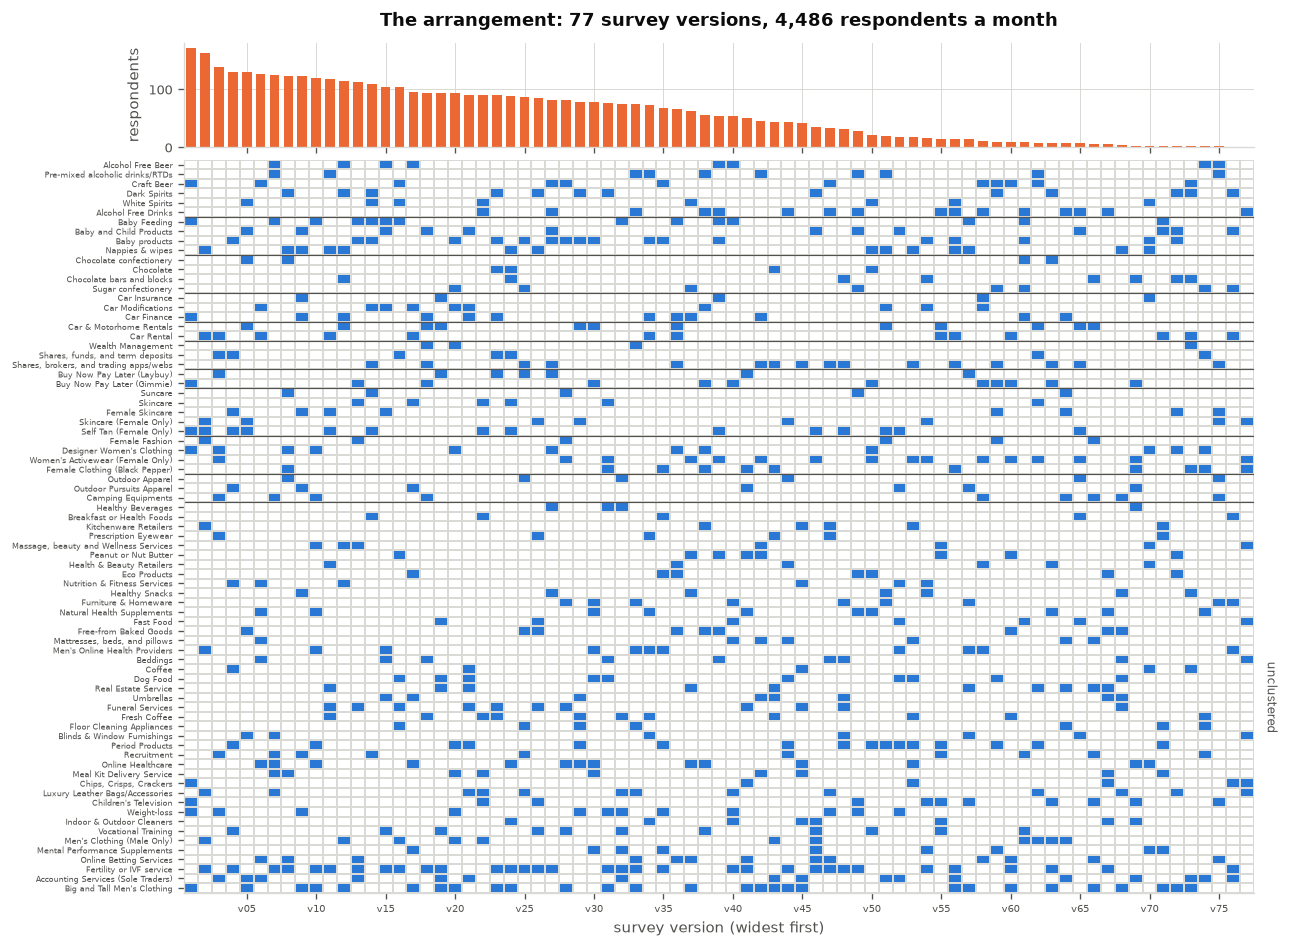

In [36]:
from matplotlib.colors import ListedColormap

# fig4 - the arrangement. Categories grouped by co-purchase cluster, versions by size.
ord_c = np.lexsort((-c, np.where(gid < 0, len(CLUSTERS), gid)))
M4 = Vf[order_v][:, ord_c].T.astype(float)

fig = plt.figure(figsize=(11.5, 9.2))
gs  = fig.add_gridspec(2, 1, height_ratios=[1, 7], hspace=0.03)
axb = fig.add_subplot(gs[0])
axm = fig.add_subplot(gs[1], sharex=axb)

axb.bar(np.arange(n_ver) + .5, xf[order_v], width=.7, color=ORANGE, linewidth=0)
axb.set_ylabel('respondents'); axb.yaxis.set_major_formatter(thousands)
axb.tick_params(labelbottom=False); axb.set_xlim(0, n_ver)
axb.set_title(f'The arrangement: {n_ver} survey versions, {xf.sum():,d} respondents a month',
              pad=10)

axm.pcolormesh(M4, cmap=ListedColormap(['#ffffff', BLUE]), vmin=0, vmax=1,
               edgecolors=GRID, linewidth=0.25)
axm.set_yticks(np.arange(n_cat) + .5)
axm.set_yticklabels([names[i][:38] for i in ord_c], fontsize=4.6)
axm.set_xticks(np.arange(4, n_ver, 5) + .5)
axm.set_xticklabels([vid[v] for v in order_v[4::5]], fontsize=6)
axm.set_xlabel('survey version (widest first)')
axm.grid(False); axm.invert_yaxis()
clu_edges = np.flatnonzero(np.diff(np.where(gid < 0, len(CLUSTERS), gid)[ord_c])) + 1
for b_ in clu_edges:
    axm.axhline(b_, color=MUTED, linewidth=0.7)
axm.text(n_ver + .8, clu_edges[-1] + (n_cat - clu_edges[-1])/2, 'unclustered', rotation=270,
         va='center', fontsize=7, color=MUTED)
fig.savefig('figures/fig4.png', dpi=150, bbox_inches='tight')
plt.show()

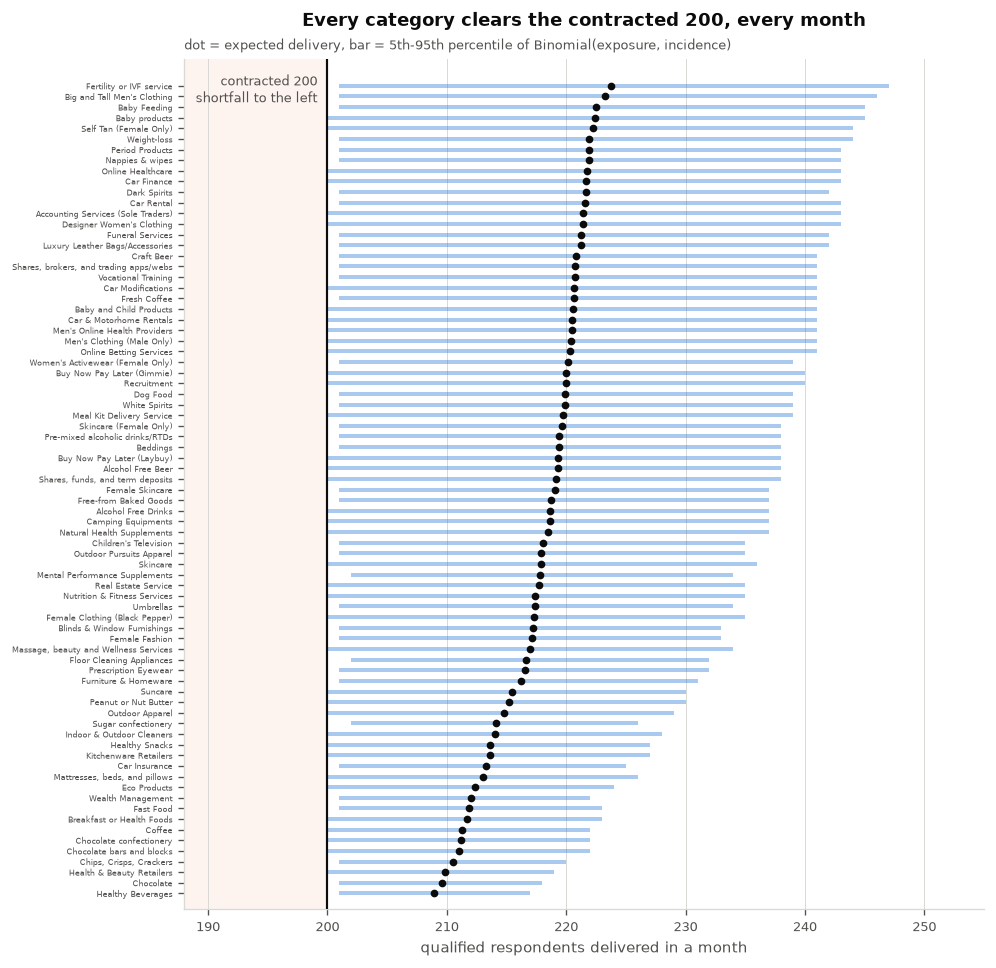

In [37]:
# fig5 - does every category clear the contracted 200 every month?
ordd = np.argsort(q_mean)
y = np.arange(n_cat)

fig, ax = plt.subplots(figsize=(8.6, 9.2))
ax.axvspan(0, NOMINAL, color=ORANGE, alpha=.07, linewidth=0, zorder=0)
ax.axvline(NOMINAL, color=INK, linewidth=1.3, zorder=4)
ax.hlines(y, q_p5[ordd], q_p95[ordd], color=BLUE, alpha=.40, linewidth=2.4, zorder=2)
ax.scatter(q_mean[ordd], y, s=13, color=INK, zorder=3)

ax.set_yticks(y); ax.set_yticklabels([names[i][:38] for i in ordd], fontsize=4.6)
ax.set_ylim(-1.5, n_cat + 1.5)
ax.set_xlim(NOMINAL - 12, float(q_p95.max()) + 8)
ax.set_xlabel('qualified respondents delivered in a month')
ax.grid(axis='y', visible=False)
ax.set_title('Every category clears the contracted 200, every month', pad=20)
ax.text(0, 1.008, 'dot = expected delivery, bar = 5th-95th percentile of Binomial(exposure, '
        'incidence)', transform=ax.transAxes, fontsize=7.5, color=MUTED, va='bottom')
ax.annotate('contracted 200\nshortfall to the left', (NOMINAL, n_cat + 0.2), xytext=(-6, 0),
            textcoords='offset points', ha='right', va='top', fontsize=8, color=MUTED)
fig.savefig('figures/fig5.png', dpi=150, bbox_inches='tight')
plt.show()